<a href="https://colab.research.google.com/github/vivianroca/proyecto/blob/master/Proyecto_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Importación de librerias**

In [244]:
# =========================================
# 1. Importación de librerías
# =========================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from google.colab import drive
import plotly.express as px
import seaborn as sns

pd.set_option('display.max_columns', None)

In [245]:
from google.colab import files
#files.upload()

# **Funciones Base**

In [246]:
# =========================================
# 2. Funciones base sugeridas
# =========================================

def cargar_csv(ruta):
    try:
        df = pd.read_csv(ruta)
        print(f'Archivo cargado correctamente: {ruta} -> {df.shape}')
        return df
    except FileNotFoundError:
        print(f'No se encontró el archivo: {ruta}')
        return None
    except Exception as e:
        print(f'Error al cargar {ruta}: {e}')
        return None

def estandarizar_columnas(df):
    df = df.copy()
    df.columns = [col.strip().lower().replace(' ', '_') for col in df.columns]
    return df

def resumen_calidad(df, nombre='dataset'):
    print(f'\n===== Resumen de calidad: {nombre} =====')
    print('Dimensiones:', df.shape)
    print('\nTipos de datos:')
    print(df.dtypes)
    print('\nValores nulos:')
    print(df.isnull().sum())
    print('\nDuplicados:', df.duplicated().sum())

def validar_columnas(df, columnas_esperadas, nombre='dataset'):
    faltantes = [col for col in columnas_esperadas if col not in df.columns]
    if faltantes:
        print(f'Columnas faltantes en {nombre}: {faltantes}')
    else:
        print(f'{nombre}: columnas completas')

def clasificar_edad(edad):
    if edad < 18:
        return 'menor'
    elif edad <= 30:
        return 'joven'
    elif edad <= 50:
        return 'adulto'
    else:
        return 'senior'

def estado_inventario(stock_actual, stock_minimo):
    if stock_actual <= stock_minimo:
        return 'critico'
    elif stock_actual <= stock_minimo * 1.5:
        return 'bajo'
    return 'normal'

def clasificar_margen(margen):
    if margen < 0.10:
        return 'muy bajo'
    elif margen < 0.20:
        return 'bajo'
    elif margen < 0.35:
        return 'medio'
    return 'alto'

def entrega_tardia(dias, umbral=3):
    return 'si' if dias > umbral else 'no'

# **Carga de Datos**

In [247]:
ruta = 'https://raw.githubusercontent.com/vivianroca/proyecto/refs/heads/master/data/'

In [248]:
# =========================================
# 3. Carga de datasets
# =========================================
clientes = cargar_csv(ruta + 'clientes.csv')
productos = cargar_csv(ruta + 'productos.csv')
ventas = cargar_csv(ruta + 'ventas.csv')
inventario = cargar_csv(ruta + 'inventario.csv')
entregas = cargar_csv(ruta + 'entregas.csv')
devoluciones = cargar_csv(ruta + 'devoluciones.csv')

Archivo cargado correctamente: https://raw.githubusercontent.com/vivianroca/proyecto/refs/heads/master/data/clientes.csv -> (257, 6)
Archivo cargado correctamente: https://raw.githubusercontent.com/vivianroca/proyecto/refs/heads/master/data/productos.csv -> (30, 6)
Archivo cargado correctamente: https://raw.githubusercontent.com/vivianroca/proyecto/refs/heads/master/data/ventas.csv -> (1800, 7)
Archivo cargado correctamente: https://raw.githubusercontent.com/vivianroca/proyecto/refs/heads/master/data/inventario.csv -> (30, 4)
Archivo cargado correctamente: https://raw.githubusercontent.com/vivianroca/proyecto/refs/heads/master/data/entregas.csv -> (1800, 6)
Archivo cargado correctamente: https://raw.githubusercontent.com/vivianroca/proyecto/refs/heads/master/data/devoluciones.csv -> (220, 5)


# **Estandarización**

> Add blockquote



In [249]:
# =========================================
# 4. Estandarización inicial
# =========================================
datasets = {
    'clientes': clientes,
    'productos': productos,
    'ventas': ventas,
    'inventario': inventario,
    'entregas': entregas,
    'devoluciones': devoluciones
}

for nombre, df in datasets.items():
    if df is not None:
        datasets[nombre] = estandarizar_columnas(df)

clientes = datasets['clientes']
productos = datasets['productos']
ventas = datasets['ventas']
inventario = datasets['inventario']
entregas = datasets['entregas']
devoluciones = datasets['devoluciones']

## **Exploracion de datos Inicial**
- Reconocer dataset
- columndas
- tipos de datos
- incosistencias



In [250]:
# =========================================
# 5. Exploracion de datos
# =========================================

print(f'----> CLIENTE \n')
print(f'{clientes.head()}\n')
print(f'\n')

print(f'Descripcion \n')
print(f'{clientes.describe()}\n')


print(f'\n----> {clientes['ciudad'].value_counts(dropna=False)} \n----------')

print(f'\n----> {clientes['segmento'].value_counts(dropna=False)} \n----------')



----> CLIENTE 

   cliente_id           nombre  edad          ciudad segmento fecha_registro
0           1  Leibniz Morales  56.0       Guatemala     alto     2025-09-27
1           2     Platón Reyes  69.0           Mixco     bajo     2026-02-06
2           3    Hannah Campos  46.0       Guatemala     bajo     2024-06-07
3           4    Voltaire León  32.0  Quetzaltenango    medio     2024-08-30
4           5     Safo Morales  60.0           Mixco     bajo     2024-06-15



Descripcion 

       cliente_id        edad
count  257.000000  249.000000
mean   124.949416   44.485944
std     72.316588   15.681842
min      1.000000   18.000000
25%     62.000000   31.000000
50%    124.000000   45.000000
75%    187.000000   58.000000
max    250.000000   70.000000


----> ciudad
Guatemala         82
Mixco             50
Villa Nueva       41
Escuintla         27
Quetzaltenango    26
Antigua           15
 Guatemala         4
guatemala          3
antigua            2
 Escuintla         2
quetzalten

In [251]:

print(f'----> VENTAS \n')
print(f'{ventas.head()}\n')
print(f'\n')

print(f'Descripcion \n')
print(f'{ventas.describe()}\n')

print(f'\n----> {ventas['canal'].value_counts(dropna=False)} \n----------')


----> VENTAS 

   venta_id       fecha  cliente_id  producto_id  cantidad   canal  descuento
0         1  2025-10-06         189           20         5     app       0.20
1         2  2026-03-09         148           18         9  online       0.00
2         3  2025-11-09         114           18         8     app       0.15
3         4  2025-12-01          78            2         2  online       0.20
4         5  2025-11-02         130            4         3  online       0.00



Descripcion 

         venta_id   cliente_id  producto_id     cantidad    descuento
count  1800.00000  1800.000000  1800.000000  1800.000000  1800.000000
mean    900.50000   393.393889   256.690556     5.557778     0.081333
std     519.75956  1524.613275  1371.363974     2.869013     0.075658
min       1.00000     1.000000     1.000000    -3.000000    -0.050000
25%     450.75000    66.750000     8.000000     3.000000     0.000000
50%     900.50000   132.000000    16.000000     6.000000     0.050000
75%    135

In [252]:


print(f'----> INVENTARIO \n')
print(f'{inventario.head()}\n')
print(f'\n')

print(f'Descripcion \n')
print(f'{inventario.describe()}\n')

print(f'\n----> {inventario['bodega'].value_counts(dropna=False)} \n----------')



----> INVENTARIO 

   producto_id  stock_actual  stock_minimo          bodega
0            1         118.0            17      Bodega Sur
1            2           6.0            31    Bodega Norte
2            3           7.0            26    Bodega Norte
3            4         157.0            31  Bodega Central
4            5          74.0            14    Bodega Norte



Descripcion 

       producto_id  stock_actual  stock_minimo
count    30.000000     29.000000     30.000000
mean     15.500000     72.896552     23.966667
std       8.803408     66.261573      7.392836
min       1.000000     -5.000000     12.000000
25%       8.250000      7.000000     18.250000
50%      15.500000     60.000000     24.000000
75%      22.750000    111.000000     27.750000
max      30.000000    194.000000     39.000000


----> bodega
Bodega Norte      13
Bodega Sur        11
Bodega Central     6
Name: count, dtype: int64 
----------


In [253]:


print(f'----> ENTREGAS \n')
print(f'{entregas.head()}\n')
print(f'\n')

print(f'Descripcion \n')
print(f'{entregas.describe()}\n')

print(f'\n----> {entregas['estado_entrega'].value_counts(dropna=False)} \n----------')
print(f'\n----> {entregas['zona'].value_counts(dropna=False)} \n----------')


----> ENTREGAS 

   entrega_id  venta_id fecha_entrega estado_entrega  tiempo_entrega_dias  \
0           1         1    2025-06-16      cancelado                    6   
1           2         2    2026-09-06      entregado                    3   
2           3         3    2025-09-13         tardío                    2   
3           4         4    2025-01-15      entregado                    3   
4           5         5    2025-02-14      entregado                    3   

        zona  
0    oriente  
1     centro  
2  occidente  
3     centro  
4     centro  



Descripcion 

       entrega_id     venta_id  tiempo_entrega_dias
count  1800.00000  1800.000000          1800.000000
mean    900.50000   957.939444             3.385556
std     519.75956   874.314945             2.014183
min       1.00000     1.000000            -2.000000
25%     450.75000   453.750000             2.000000
50%     900.50000   905.500000             3.000000
75%    1350.25000  1361.250000             5.0000

In [254]:

print(f'----> ENTREGAS \n')
print(f'{devoluciones.head()}\n')
print(f'\n')

print(f'Descripcion \n')
print(f'{devoluciones.describe()}\n')

print(f'\n----> {devoluciones['motivo'].value_counts(dropna=False)} \n----------')


----> ENTREGAS 

   devolucion_id  venta_id               motivo  monto_devuelto  \
0              1      1592          no le gustó          259.08   
1              2       944          no le gustó         2021.91   
2              3       870          no le gustó         3282.18   
3              4       163       entrega tardía         2149.41   
4              5      9705  producto incorrecto         2457.58   

  fecha_devolucion  
0       2026-05-04  
1       2026-06-19  
2       2026-03-06  
3       2026-03-04  
4       2026-03-17  



Descripcion 

       devolucion_id     venta_id  monto_devuelto
count     220.000000   220.000000      220.000000
mean      110.500000  1242.100000     1283.559364
std        63.652704  1733.491646     1307.941725
min         1.000000    24.000000      -50.000000
25%        55.750000   518.000000      331.715000
50%       110.500000   907.000000      942.945000
75%       165.250000  1400.250000     1899.810000
max       220.000000  9797.000000    

**Conclusiones:**

Existen varias inconsistencias en los datasets, por lo que se implementaran diferentes funciones de validaciones de datos

# **Funciones de Valiacion de datos**

- Implementacion de funciones de validacion
  - nulos
  - duplicados
  - valores negativos
  - rangos
  - fechas

- Validacion de columnas esperadas

In [255]:
# =========================================
# 6. Validacion de calidad de datos
# =========================================


# duplicados
def validar_duplicados(df, columnas_id, nombre='dataset'):
    duplicados = df[df.duplicated(subset=columnas_id, keep=False)]
    print(f'\n---> Duplicados en {nombre} <---')
    print(f'Total duplicados segun {columnas_id}: {duplicados.shape[0]}')
    return duplicados

# nulos
def validar_nulos(df, nombre='dataset'):
    nulos = df.isnull().sum()
    nulos = nulos[nulos > 0].sort_values(ascending=False)
    print(f'\n---> Valores nulos en {nombre} <---')
    if len(nulos) == 0:
        print('No se encontraron valores nulos')
    else:
        print(nulos)
    return nulos

#negativos o cero
def validar_valores_negativos_o_cero(df, columna, nombre='dataset', permitir_cero=False):
    if permitir_cero:
        malos = df[df[columna] < 0]
    else:
        malos = df[df[columna] <= 0]
    print(f'\n---> Validacion de {columna} en {nombre} <---')
    print(f'Registros problemáticos: {malos.shape[0]}')
    return malos

# rangos
def validar_rango(df, columna, minimo=None, maximo=None, nombre='dataset'):
    condicion = pd.Series([False] * len(df), index=df.index)

    if minimo is not None:
        condicion = condicion | (df[columna] < minimo)

    if maximo is not None:
        condicion = condicion | (df[columna] > maximo)

    resultado = df[condicion]
    print(f'\n---> Validacion de rango en {nombre}.{columna} <---')
    print(f'Registros fuera de rango: {resultado.shape[0]}')
    return resultado

#fechas
def validar_fechas(df, columna, nombre='dataset'):
    fechas = pd.to_datetime(df[columna], errors='coerce')
    invalidas = df[fechas.isna()]
    print(f'\n---> Validacion de fechas en {nombre}.{columna} <---')
    print(f'Fechas no validas: {invalidas.shape[0]}')
    return invalidas

def validar_referencias(df_origen, col_origen, df_ref, col_ref, nombre='dataset'):
    invalidos = df_origen[~df_origen[col_origen].isin(df_ref[col_ref])]
    print(f'\n---> Validacion de referencia: {nombre}.{col_origen} -> {col_ref} ---')
    print(f'Referencias rotas: {invalidos.shape[0]}')
    return invalidos

#resumen general para desplegar informacion

def resumen_general_calidad(nombre, df):
    resumen = {
        '-> dataset': nombre,
        '-> filas': df.shape[0],
        '-> columnas': df.shape[1],
        '-> nulos totales': int(df.isnull().sum().sum()),
        '-> duplicados totales': int(df.duplicated().sum())
    }
    return resumen

In [256]:
# =========================================
# 6.1 Validaciones por dataset
# =========================================

# Columnas esperadas
columnas_clientes = [
    'cliente_id'
  , 'nombre'
  , 'edad'
  , 'ciudad'
  , 'segmento'
  , 'fecha_registro'
  ]
columnas_productos = [
    'producto_id'
    , 'nombre_producto'
    , 'categoria'
    , 'precio'
    , 'costo'
    , 'proveedor'
    ]
columnas_ventas = [
    'venta_id'
    , 'fecha'
    , 'cliente_id'
    , 'producto_id'
    , 'cantidad'
    , 'canal'
    , 'descuento'
    ]
columnas_inventario = [
    'producto_id'
    , 'stock_actual'
    , 'stock_minimo'
    , 'bodega'
    ]
columnas_entregas = [
    'entrega_id'
    , 'venta_id'
    , 'fecha_entrega'
    , 'estado_entrega'
    , 'tiempo_entrega_dias'
    , 'zona'
    ]
columnas_devoluciones = [
    'devolucion_id'
    , 'venta_id'
    , 'motivo'
    , 'monto_devuelto'
    , 'fecha_devolucion'
    ]

validar_columnas(clientes
                 , columnas_clientes
                 , 'clientes')

validar_columnas(productos
                 , columnas_productos
                 , 'productos')

validar_columnas(ventas
                 , columnas_ventas
                 , 'ventas')

validar_columnas(inventario
                 , columnas_inventario
                 , 'inventario')

validar_columnas(entregas
                 , columnas_entregas
                 , 'entregas')

validar_columnas(devoluciones
                 , columnas_devoluciones
                 , 'devoluciones')

clientes: columnas completas
productos: columnas completas
ventas: columnas completas
inventario: columnas completas
entregas: columnas completas
devoluciones: columnas completas


# **Reporte Inicial de Calidad**

In [257]:
# =========================================
# 6.2 Resumen inicial de calidad
# =========================================

resumenes = []
for nombre, df in datasets.items():
    if df is not None:
        resumen_calidad(df, nombre)
        resumenes.append(resumen_general_calidad(nombre, df))

resumen_calidad_df = pd.DataFrame(resumenes)
print('\n===== Resumen general de calidad =====')
display(resumen_calidad_df)


===== Resumen de calidad: clientes =====
Dimensiones: (257, 6)

Tipos de datos:
cliente_id          int64
nombre             object
edad              float64
ciudad             object
segmento           object
fecha_registro     object
dtype: object

Valores nulos:
cliente_id        0
nombre            0
edad              8
ciudad            0
segmento          0
fecha_registro    0
dtype: int64

Duplicados: 7

===== Resumen de calidad: productos =====
Dimensiones: (30, 6)

Tipos de datos:
producto_id          int64
nombre_producto     object
categoria           object
precio             float64
costo              float64
proveedor           object
dtype: object

Valores nulos:
producto_id        0
nombre_producto    0
categoria          0
precio             0
costo              0
proveedor          1
dtype: int64

Duplicados: 0

===== Resumen de calidad: ventas =====
Dimensiones: (1800, 7)

Tipos de datos:
venta_id         int64
fecha           object
cliente_id       int64
producto_

,-> dataset,-> filas,-> columnas,-> nulos totales,-> duplicados totales
0,clientes,257,6,8,7
1,productos,30,6,1,0
2,ventas,1800,7,0,0
3,inventario,30,4,1,0
4,entregas,1800,6,0,0
5,devoluciones,220,5,0,0


## **Validaciones especificas de columnas y datasets**

In [258]:
# =========================================
# 6.3 Validaciones especificas
# =========================================

#validamos ya con las funciones que se implementaron

# CLIENTES
dup_clientes = validar_duplicados(clientes
                                  , ['cliente_id']
                                  , 'clientes')

nulos_clientes = validar_nulos(clientes
                               , 'clientes')

fechas_invalidas_clientes = validar_fechas(clientes
                                           , 'fecha_registro'
                                           , 'clientes'
                                           )

# PRODUCTOS
dup_productos = validar_duplicados(productos
                                   , ['producto_id']
                                   , 'productos')

nulos_productos = validar_nulos(productos, 'productos')

precio_invalido = validar_valores_negativos_o_cero(productos
                                                   , 'precio'
                                                   , 'productos'
                                                   , permitir_cero=False)

costo_invalido = validar_valores_negativos_o_cero(productos
                                                  , 'costo'
                                                  , 'productos'
                                                  , permitir_cero=False)

costo_mayor_precio = productos[productos['costo'] > productos['precio']]

print(f'\n--- Productos con costo mayor al precio ---')
print(f'Registros problemáticos: {costo_mayor_precio.shape[0]}')

# VENTAS
dup_ventas = validar_duplicados(ventas
                                , ['venta_id']
                                , 'ventas')

nulos_ventas = validar_nulos(ventas, 'ventas')

cantidades_invalidas = validar_valores_negativos_o_cero(ventas
                                                        , 'cantidad'
                                                        , 'ventas'
                                                        , permitir_cero=False)

descuentos_invalidos = validar_rango(ventas
                                     , 'descuento'
                                     , minimo=0
                                     , maximo=0.30
                                     , nombre='ventas')

fechas_invalidas_ventas = validar_fechas(ventas
                                         , 'fecha'
                                         , 'ventas')

# INVENTARIO
dup_inventario = validar_duplicados(inventario
                                    , ['producto_id']
                                    , 'inventario')

nulos_inventario = validar_nulos(inventario, 'inventario')

stock_actual_invalido = validar_rango(inventario
                                      , 'stock_actual'
                                      , minimo=0
                                      , nombre='inventario')

stock_minimo_invalido = validar_rango(inventario
                                      , 'stock_minimo'
                                      , minimo=0
                                      , nombre='inventario')

# ENTREGAS
dup_entregas = validar_duplicados(entregas
                                  , ['entrega_id']
                                  , 'entregas')

nulos_entregas = validar_nulos(entregas
                               , 'entregas')

fechas_invalidas_entregas = validar_fechas(entregas
                                           , 'fecha_entrega'
                                           , 'entregas')

tiempos_invalidos = validar_rango(entregas
                                  , 'tiempo_entrega_dias'
                                  , minimo=0
                                  , nombre='entregas')

# DEVOLUCIONES
dup_devoluciones = validar_duplicados(devoluciones
                                      , ['devolucion_id']
                                      , 'devoluciones')

nulos_devoluciones = validar_nulos(devoluciones
                                   , 'devoluciones')

fechas_invalidas_devoluciones = validar_fechas(devoluciones
                                               , 'fecha_devolucion'
                                               , 'devoluciones')

monto_devuelto_invalido = validar_rango(devoluciones
                                        , 'monto_devuelto'
                                        , minimo=0
                                        , nombre='devoluciones')


---> Duplicados en clientes <---
Total duplicados segun ['cliente_id']: 14

---> Valores nulos en clientes <---
edad    8
dtype: int64

---> Validacion de fechas en clientes.fecha_registro <---
Fechas no validas: 0

---> Duplicados en productos <---
Total duplicados segun ['producto_id']: 0

---> Valores nulos en productos <---
proveedor    1
dtype: int64

---> Validacion de precio en productos <---
Registros problemáticos: 2

---> Validacion de costo en productos <---
Registros problemáticos: 0

--- Productos con costo mayor al precio ---
Registros problemáticos: 3

---> Duplicados en ventas <---
Total duplicados segun ['venta_id']: 0

---> Valores nulos en ventas <---
No se encontraron valores nulos

---> Validacion de cantidad en ventas <---
Registros problemáticos: 8

---> Validacion de rango en ventas.descuento <---
Registros fuera de rango: 10

---> Validacion de fechas en ventas.fecha <---
Fechas no validas: 8

---> Duplicados en inventario <---
Total duplicados segun ['product

## **Validaciones de Referencias Rotas Entre Tablas**

El ID de una tabla no existe en otra

In [259]:
# =========================================
# 6.4 Validacion de referencias entre tablas
# =========================================

ventas_cliente_invalido = validar_referencias(ventas
                                              , 'cliente_id'
                                              , clientes
                                              , 'cliente_id'
                                              , 'ventas')

ventas_producto_invalido = validar_referencias(ventas
                                               , 'producto_id'
                                               , productos
                                               , 'producto_id'
                                               , 'ventas')

entregas_venta_invalida = validar_referencias(entregas
                                              , 'venta_id'
                                              , ventas
                                              , 'venta_id'
                                              , 'entregas')

devoluciones_venta_invalida = validar_referencias(devoluciones
                                                  , 'venta_id'
                                                  , ventas
                                                  , 'venta_id'
                                                  , 'devoluciones')

inventario_producto_invalido = validar_referencias(inventario
                                                   , 'producto_id'
                                                   , productos
                                                   , 'producto_id'
                                                   , 'inventario')


---> Validacion de referencia: ventas.cliente_id -> cliente_id ---
Referencias rotas: 54

---> Validacion de referencia: ventas.producto_id -> producto_id ---
Referencias rotas: 54

---> Validacion de referencia: entregas.venta_id -> venta_id ---
Referencias rotas: 12

---> Validacion de referencia: devoluciones.venta_id -> venta_id ---
Referencias rotas: 8

---> Validacion de referencia: inventario.producto_id -> producto_id ---
Referencias rotas: 0


## **Hallazgos Totales**

In [260]:
# =========================================
# 6.5 Tabla consolidada de hallazgos
# =========================================

hallazgos = [
    ['clientes', 'duplicados cliente_id', dup_clientes.shape[0]],
    ['clientes', 'nulos'                , int(clientes.isnull().sum().sum())],
    ['clientes', 'fechas_invalidas'     , fechas_invalidas_clientes.shape[0]],

    ['productos', 'duplicados producto_id', dup_productos.shape[0]],
    ['productos', 'nulos'                 , int(productos.isnull().sum().sum())],
    ['productos', 'precio_invalido'       , precio_invalido.shape[0]],
    ['productos', 'costo_invalido'        , costo_invalido.shape[0]],
    ['productos', 'costo_mayor_precio'    , costo_mayor_precio.shape[0]],

    ['ventas', 'duplicados venta_id'      , dup_ventas.shape[0]],
    ['ventas', 'nulos'                    , int(ventas.isnull().sum().sum())],
    ['ventas', 'cantidad_invalida'        , cantidades_invalidas.shape[0]],
    ['ventas', 'descuento_fuera_rango'    , descuentos_invalidos.shape[0]],
    ['ventas', 'fechas_invalidas'         , fechas_invalidas_ventas.shape[0]],
    ['ventas', 'cliente_id_inexistente'   , ventas_cliente_invalido.shape[0]],
    ['ventas', 'producto_id_inexistente'  , ventas_producto_invalido.shape[0]],

    ['inventario', 'duplicados producto_id' , dup_inventario.shape[0]],
    ['inventario', 'nulos'                  , int(inventario.isnull().sum().sum())],
    ['inventario', 'stock_actual_invalido'  , stock_actual_invalido.shape[0]],
    ['inventario', 'stock_minimo_invalido'  , stock_minimo_invalido.shape[0]],
    ['inventario', 'producto_id_inexistente', inventario_producto_invalido.shape[0]],

    ['entregas', 'duplicados entrega_id'    , dup_entregas.shape[0]],
    ['entregas', 'nulos'                    , int(entregas.isnull().sum().sum())],
    ['entregas', 'fechas_invalidas'         , fechas_invalidas_entregas.shape[0]],
    ['entregas', 'tiempo_entrega_invalido'  , tiempos_invalidos.shape[0]],
    ['entregas', 'venta_id_inexistente'     , entregas_venta_invalida.shape[0]],

    ['devoluciones', 'duplicados devolucion_id' , dup_devoluciones.shape[0]],
    ['devoluciones', 'nulos'                    , int(devoluciones.isnull().sum().sum())],
    ['devoluciones', 'fechas_invalidas'         , fechas_invalidas_devoluciones.shape[0]],
    ['devoluciones', 'monto_devuelto_invalido'  , monto_devuelto_invalido.shape[0]],
    ['devoluciones', 'venta_id_inexistente'     , devoluciones_venta_invalida.shape[0]],
]

tabla_hallazgos = pd.DataFrame(hallazgos, columns=['dataset', 'validacion', 'cantidad'])

print('\n=====>> Tabla consolidada de hallazgos <<=====')
display(tabla_hallazgos)


=====>> Tabla consolidada de hallazgos <<=====


,dataset,validacion,cantidad
0,clientes,duplicados cliente_id,14
1,clientes,nulos,8
2,clientes,fechas_invalidas,0
3,productos,duplicados producto_id,0
4,productos,nulos,1
5,productos,precio_invalido,2
6,productos,costo_invalido,0
7,productos,costo_mayor_precio,3
8,ventas,duplicados venta_id,0
9,ventas,nulos,0


# **Conclusiones**

Se encontraron varias incosistencias
- Nulos
- Duplicados
- Valores fuera de rango
- Referencias rotas entre tablas

Importante identicar las tablas de mayor importancia, las cuales son
- Ventas
- Productos
- Devoluciones

Esto de acuerdo a que con ellas se calculan metricas criticas del negocio.

Debido a esto antes de hacer el merge de los datos hay que aplicar procesos de
- limpieza de datos
- normalizacion de columnas
- validaciones cruzadas

A continuacion se implementaran.

# **Limpieza y Preparacion de Datos**

- Corregir/normalizar valores no validos en precios, costos, cantidades y descuentos
- Inferir valores faltantes utilizando medianas
- Normalizar textos en valores categoricos
- Eliminar registros con referencias inexistentes para asegurar la integridad en cada dataset
- Se normalizaron fechas para asegurar la integridad de la temporalidad

Esto permite que los dataset queden limpios, es decir asegurar la integridad para su posterior analisis.



In [261]:
# =========================================
# 7. Limpieza y preparacion
# =========================================

# Hacemos copias, importante no perder las fuentes originales

clientes_clean = clientes.copy()

productos_clean = productos.copy()

ventas_clean = ventas.copy()

inventario_clean = inventario.copy()

entregas_clean = entregas.copy()

devoluciones_clean = devoluciones.copy()

In [262]:
# ----- CLIENTES -----

# normalizar columnas de texto
#ciudad
clientes_clean['ciudad'] = (
    clientes_clean['ciudad']
    .astype(str) #convertir a texto
    .str.strip() #eliminar espacios
    .str.title() #nombre propio
    )

clientes_clean['ciudad'].value_counts(dropna=False)



,count
ciudad,
Guatemala,91
Mixco,51
Villa Nueva,41
Escuintla,29
Quetzaltenango,28
Antigua,17


In [263]:
#segmento
clientes_clean['segmento'] = (
    clientes_clean['segmento']
    .astype(str)
    .str.strip()
    .str.lower() #todo a minuscula
)

segmentos_validos = ['alto', 'medio', 'bajo']

clientes_clean.loc[
    ~clientes_clean['segmento'].isin(segmentos_validos),
    'segmento'
] = 'No definido' #nan tambien va a no definido

clientes_clean['segmento'].value_counts(dropna=False)

,count
segmento,
medio,137
bajo,74
alto,46


In [264]:
# Inferir la edad con la mediana para eliminar outliners
edad_mediana = clientes_clean['edad'].median()
clientes_clean['edad'] = clientes_clean['edad'].fillna(edad_mediana)

# Convertir fechas
clientes_clean['fecha_registro'] = pd.to_datetime(clientes_clean['fecha_registro'], errors='coerce')

# Eliminar duplicados por cliente_id, se tomara el primero
clientes_clean = clientes_clean.drop_duplicates(subset=['cliente_id'])

#Agregar rango de edad, ademas de la funcion base dada
clientes_clean['grupo_edad'] = clientes_clean['edad'].apply(clasificar_edad)

clientes_clean['grupo_edad_rango'] = pd.cut(
    clientes_clean['edad'],
    bins=[0, 18, 25, 35, 45, 55, 100],
    labels=['a) menor de edad', 'b) 18 - 24', 'c) 25 - 34', 'd) 35 - 44', 'e) 45 - 54', 'f) mas de 55']
)
clientes_clean.head()


,cliente_id,nombre,edad,ciudad,segmento,fecha_registro,grupo_edad,grupo_edad_rango
0,1,Leibniz Morales,56.0,Guatemala,alto,2025-09-27,senior,f) mas de 55
1,2,Platón Reyes,69.0,Mixco,bajo,2026-02-06,senior,f) mas de 55
2,3,Hannah Campos,46.0,Guatemala,bajo,2024-06-07,adulto,e) 45 - 54
3,4,Voltaire León,32.0,Quetzaltenango,medio,2024-08-30,adulto,c) 25 - 34
4,5,Safo Morales,60.0,Mixco,bajo,2024-06-15,senior,f) mas de 55


In [265]:
# ----- VENTAS -----

# canal
ventas_clean['canal'] = (
    ventas_clean['canal']
    .astype(str)
    .str.strip()
    .str.lower()
)

#catalogo de canales
canales_validos = ['online', 'tienda', 'app']

canal_invalido = ventas[
    ~ventas['canal'].astype(str).str.strip().str.lower().isin(canales_validos)
]

ventas_clean.loc[
    ~ventas_clean['canal'].isin(canales_validos),
    'canal'
] = 'No definido'

ventas_clean['canal'].value_counts(dropna=False)


,count
canal,
online,828
tienda,610
app,362


In [266]:

# Cantidades no validas: eliminar (afectan métricas directamente)
ventas_clean = ventas_clean[ventas_clean['cantidad'] > 0]

# Descuentos fuera de rango: outliners
ventas_clean.loc[ventas_clean['descuento'] < 0, 'descuento'] = 0
ventas_clean.loc[ventas_clean['descuento'] > 0.30, 'descuento'] = 0.30

# Fechas
ventas_clean['fecha'] = pd.to_datetime(ventas_clean['fecha'], errors='coerce')

# Eliminar fechas no validas
ventas_clean = ventas_clean.dropna(subset=['fecha'])

ventas_clean.head()

,venta_id,fecha,cliente_id,producto_id,cantidad,canal,descuento
0,1,2025-10-06,189,20,5,app,0.20
1,2,2026-03-09,148,18,9,online,0.00
2,3,2025-11-09,114,18,8,app,0.15
3,4,2025-12-01,78,2,2,online,0.20
4,5,2025-11-02,130,4,3,online,0.00


In [267]:
# ----- PRODUCTOS -----

# Precios menores a 0
productos_clean.loc[productos_clean['precio'] <= 0, 'precio'] = np.nan

# Costos no valiados
productos_clean.loc[productos_clean['costo'] <= 0, 'costo'] = np.nan

# Si costo > precio , inferir
mask = productos_clean['costo'] > productos_clean['precio']

# Si el costo es mayor que el precio, el costo es el 70% del precio
# no es comun pero podria suceder
productos_clean.loc[mask, 'costo'] = productos_clean.loc[mask, 'precio'] * 0.7

# Inferir valores faltantes, con la mediana de cada columna
#precio
productos_clean['precio'] = productos_clean['precio'].fillna(productos_clean['precio'].median())
#costo
productos_clean['costo'] = productos_clean['costo'].fillna(productos_clean['costo'].median())

# Proveedor nulo
productos_clean['proveedor'] = productos_clean['proveedor'].fillna('No definido')

productos_clean.head()

,producto_id,nombre_producto,categoria,precio,costo,proveedor
0,1,Auriculares Nova,Tecnología,320.55,310.930,Argos Comercial
1,2,Teclado Cronos,Tecnología,41.90,39.800,Grupo Helios
2,3,Mouse Apolo,Tecnología,320.15,257.420,Grupo Helios
3,4,Monitor Gaia,Tecnología,320.15,342.440,Mercurio Retail
4,5,Router Apolo,Tecnología,595.48,416.836,Proveedor Atenea


In [268]:
# ----- INVENTARIO -----

# Valores negativos a NaN

inventario_clean.loc[inventario_clean['stock_actual'] < 0, 'stock_actual'] = np.nan

inventario_clean.loc[inventario_clean['stock_minimo'] < 0, 'stock_minimo'] = np.nan

# Inferir
#Nan a 0
inventario_clean['stock_actual'] = inventario_clean['stock_actual'].fillna(0)

#Nan a mediana
inventario_clean['stock_minimo'] = inventario_clean['stock_minimo'].fillna(inventario_clean['stock_minimo'].median())

inventario_clean.head()

,producto_id,stock_actual,stock_minimo,bodega
0,1,118.0,17.0,Bodega Sur
1,2,6.0,31.0,Bodega Norte
2,3,7.0,26.0,Bodega Norte
3,4,157.0,31.0,Bodega Central
4,5,74.0,14.0,Bodega Norte


In [269]:
# ----- ENTREGAS -----

# Fechas
entregas_clean['fecha_entrega'] = pd.to_datetime(entregas_clean['fecha_entrega'], errors='coerce')

# Tiempos de entregas no validas
#menor a 0  Nan
entregas_clean.loc[entregas_clean['tiempo_entrega_dias'] < 0, 'tiempo_entrega_dias'] = np.nan

#mayor a 15 Nan
entregas_clean.loc[entregas_clean['tiempo_entrega_dias'] > 15, 'tiempo_entrega_dias'] = np.nan

# Inferir tiempos
# Nan a medianas
entregas_clean['tiempo_entrega_dias'] = entregas_clean['tiempo_entrega_dias'].fillna(
    entregas_clean['tiempo_entrega_dias'].median()
)

entregas_clean.head()

,entrega_id,venta_id,fecha_entrega,estado_entrega,tiempo_entrega_dias,zona
0,1,1,2025-06-16,cancelado,6.0,oriente
1,2,2,2026-09-06,entregado,3.0,centro
2,3,3,2025-09-13,tardío,2.0,occidente
3,4,4,2025-01-15,entregado,3.0,centro
4,5,5,2025-02-14,entregado,3.0,centro


In [270]:
# ----- DEVOLUCIONES -----

# Texto
devoluciones_clean['motivo'] = (
    devoluciones_clean['motivo']
    .astype(str)
    .str.strip()
    .str.lower()
)

# Normalizar motivos
devoluciones_clean['motivo'] = devoluciones_clean['motivo'].replace({
    'defectuoso': 'defectuoso',
    'entrega tardía': 'entrega tardia',
    'no le gustó': 'no le gusto'
})

# catalogo validado
motivos_validos = [
    'defectuoso',
    'entrega tardia',
    'no le gusto',
    'producto incorrecto'
]

devoluciones_clean['motivo'].value_counts(dropna=False)


,count
motivo,
defectuoso,71
entrega tardia,56
no le gusto,55
producto incorrecto,38


In [271]:

devoluciones_clean.loc[
    ~devoluciones_clean['motivo'].isin(motivos_validos),
    'motivo'
] = 'No definido'

# Montos outliners
devoluciones_clean.loc[devoluciones_clean['monto_devuelto'] < 0, 'monto_devuelto'] = np.nan

# inferirs
devoluciones_clean['monto_devuelto'] = devoluciones_clean['monto_devuelto'].fillna(
    devoluciones_clean['monto_devuelto'].median()
)

# Fechas
devoluciones_clean['fecha_devolucion'] = pd.to_datetime(devoluciones_clean['fecha_devolucion'], errors='coerce')

devoluciones_clean.head()

,devolucion_id,venta_id,motivo,monto_devuelto,fecha_devolucion
0,1,1592,no le gusto,259.08,2026-05-04
1,2,944,no le gusto,2021.91,2026-06-19
2,3,870,no le gusto,3282.18,2026-03-06
3,4,163,entrega tardia,2149.41,2026-03-04
4,5,9705,producto incorrecto,2457.58,2026-03-17


In [272]:
 # RELACIONES ROTAS
# si el id cliente en venta no esta en maestro de clientes borra
ventas_clean = ventas_clean[ventas_clean['cliente_id']
                            .isin(clientes_clean['cliente_id'])]

# si el id de producto en venta no esta en maestro de productos borra
ventas_clean = ventas_clean[ventas_clean['producto_id']
                            .isin(productos_clean['producto_id'])]

# si la venta id en entrega no esta en el maestro de ventas borra
entregas_clean = entregas_clean[entregas_clean['venta_id']
                                .isin(ventas_clean['venta_id'])]

# si la venta id de devoluciones no esta en el maestro de ventas borra
devoluciones_clean = devoluciones_clean[devoluciones_clean['venta_id']
                                        .isin(ventas_clean['venta_id'])]

# **Transformaciones de Datos**

In [273]:
# =========================================
# 8. Transformaciones de datos
# =========================================

# ----- CLIENTES -----

clientes_clean['antiguedad_dias'] = (
    pd.Timestamp.today() - clientes_clean['fecha_registro']
).dt.days

def clasificar_antiguedad(dias):
    if dias < 180:
        return 'nuevo'
    elif dias < 365:
        return 'reciente'
    else:
        return 'antiguo'

clientes_clean['tipo_cliente'] = clientes_clean['antiguedad_dias'].apply(clasificar_antiguedad)

clientes_clean.head()

,cliente_id,nombre,edad,ciudad,segmento,fecha_registro,grupo_edad,grupo_edad_rango,antiguedad_dias,tipo_cliente
0,1,Leibniz Morales,56.0,Guatemala,alto,2025-09-27,senior,f) mas de 55,194,reciente
1,2,Platón Reyes,69.0,Mixco,bajo,2026-02-06,senior,f) mas de 55,62,nuevo
2,3,Hannah Campos,46.0,Guatemala,bajo,2024-06-07,adulto,e) 45 - 54,671,antiguo
3,4,Voltaire León,32.0,Quetzaltenango,medio,2024-08-30,adulto,c) 25 - 34,587,antiguo
4,5,Safo Morales,60.0,Mixco,bajo,2024-06-15,senior,f) mas de 55,663,antiguo


In [274]:
# ----- PRODUCTOS -----

#calcula el margen unitario: precio - costo, para la rentabilidad
productos_clean['margen_unitario'] = productos_clean['precio'] - productos_clean['costo']

#calcula el porcentaje: margen unitario divido el precio, indica cuanto porcentaje de rentabilidad tiene cada producto
productos_clean['margen_porcentaje'] = np.where(
    productos_clean['precio'] > 0,
    productos_clean['margen_unitario'] / productos_clean['precio'],
    0
)

#segmentacion de rentabilidad de producto
productos_clean['rentabilidad_producto'] = productos_clean['margen_porcentaje'].apply(clasificar_margen)

productos_clean.head()

,producto_id,nombre_producto,categoria,precio,costo,proveedor,margen_unitario,margen_porcentaje,rentabilidad_producto
0,1,Auriculares Nova,Tecnología,320.55,310.930,Argos Comercial,9.620,0.030011,muy bajo
1,2,Teclado Cronos,Tecnología,41.90,39.800,Grupo Helios,2.100,0.050119,muy bajo
2,3,Mouse Apolo,Tecnología,320.15,257.420,Grupo Helios,62.730,0.195939,bajo
3,4,Monitor Gaia,Tecnología,320.15,342.440,Mercurio Retail,-22.290,-0.069624,muy bajo
4,5,Router Apolo,Tecnología,595.48,416.836,Proveedor Atenea,178.644,0.300000,medio


In [275]:
# ----- INVENTARIO -----

inventario_clean['estado_inventario'] = inventario_clean.apply(
    lambda row: estado_inventario(row['stock_actual'], row['stock_minimo']),
    axis=1
)

inventario_clean['stock_critico'] = np.where(
    inventario_clean['stock_actual'] < inventario_clean['stock_minimo'],
    'si',
    'no'
)

inventario_clean.head()

,producto_id,stock_actual,stock_minimo,bodega,estado_inventario,stock_critico
0,1,118.0,17.0,Bodega Sur,normal,no
1,2,6.0,31.0,Bodega Norte,critico,si
2,3,7.0,26.0,Bodega Norte,critico,si
3,4,157.0,31.0,Bodega Central,normal,no
4,5,74.0,14.0,Bodega Norte,normal,no


In [276]:
# ----- ENTREGAS -----

#segmentamos con la funcion dada
entregas_clean['entrega_tardia'] = entregas_clean['tiempo_entrega_dias'].apply(entrega_tardia)

entregas_clean.head()

,entrega_id,venta_id,fecha_entrega,estado_entrega,tiempo_entrega_dias,zona,entrega_tardia
0,1,1,2025-06-16,cancelado,6.0,oriente,si
1,2,2,2026-09-06,entregado,3.0,centro,no
2,3,3,2025-09-13,tardío,2.0,occidente,no
3,4,4,2025-01-15,entregado,3.0,centro,no
4,5,5,2025-02-14,entregado,3.0,centro,no


In [277]:
# ----- VENTAS -----

# eliminar columnas por si acaso se ejecuta mas de una vez
ventas_clean = ventas_clean.drop(columns=['precio', 'costo'], errors='ignore')

#join tablas, para obtener el costo y precio para posterior calculo de metricas
ventas_clean = ventas_clean.merge(
    productos_clean[['producto_id', 'precio', 'costo']],
    on='producto_id',
    how='left'
)

# metricas luego del join

#ingreso
ventas_clean['ingreso_bruto'] = ventas_clean['cantidad'] * ventas_clean['precio']

#descuento al ingreso bruto
ventas_clean['descuento_aplicado'] = ventas_clean['ingreso_bruto'] * ventas_clean['descuento']

#ingreso neto, bruto - descuento
ventas_clean['ingreso_neto'] = ventas_clean['ingreso_bruto'] - ventas_clean['descuento_aplicado']

# (-) costo total, cantidad multiplicado por el costo
ventas_clean['costo_total'] = ventas_clean['cantidad'] * ventas_clean['costo']

# (+) zganancia, ingreso neto  menos el costo total
ventas_clean['ganancia'] = ventas_clean['ingreso_neto'] - ventas_clean['costo_total']

#margen de ventas, ganancia dividido el ingreso
ventas_clean['margen'] = np.where(
    ventas_clean['ingreso_neto'] > 0,
    ventas_clean['ganancia'] / ventas_clean['ingreso_neto'],
    0
)

# Variables de tiempo
ventas_clean['mes'] = ventas_clean['fecha'].dt.to_period('M').astype(str)
ventas_clean['anio'] = ventas_clean['fecha'].dt.year
ventas_clean['trimestre'] = 'Q' + ventas_clean['fecha'].dt.quarter.astype(str)

ventas_clean.head()

,venta_id,fecha,cliente_id,producto_id,cantidad,canal,descuento,precio,costo,ingreso_bruto,descuento_aplicado,ingreso_neto,costo_total,ganancia,margen,mes,anio,trimestre
0,1,2025-10-06,189,20,5,app,0.20,161.29,87.72,806.45,161.290,645.160,438.60,206.560,0.320169,2025-10,2025,Q4
1,2,2026-03-09,148,18,9,online,0.00,30.19,20.69,271.71,0.000,271.710,186.21,85.500,0.314674,2026-03,2026,Q1
2,3,2025-11-09,114,18,8,app,0.15,30.19,20.69,241.52,36.228,205.292,165.52,39.772,0.193734,2025-11,2025,Q4
3,4,2025-12-01,78,2,2,online,0.20,41.90,39.80,83.80,16.760,67.040,79.60,-12.560,-0.187351,2025-12,2025,Q4
4,5,2025-11-02,130,4,3,online,0.00,320.15,342.44,960.45,0.000,960.450,1027.32,-66.870,-0.069624,2025-11,2025,Q4


In [278]:
#clasifica la rentabilidad
ventas_clean['rentabilidad_venta'] = ventas_clean['margen'].apply(clasificar_margen)


In [279]:
#busca si la venta tiene devoluciones y marca si o no
ventas_clean['tiene_devolucion'] = np.where(
    ventas_clean['venta_id'].isin(devoluciones_clean['venta_id']),
    'si',
    'no'
)

In [280]:
#integridad de datos
print("Datos Finales Afectados - Transformados: \n")

resumen_datasets = pd.DataFrame({
    'dataset': ['clientes', 'productos', 'ventas', 'inventario', 'entregas', 'devoluciones'],
    'filas': [
        clientes_clean.shape[0],
        productos_clean.shape[0],
        ventas_clean.shape[0],
        inventario_clean.shape[0],
        entregas_clean.shape[0],
        devoluciones_clean.shape[0]
    ],
    'columnas': [
        clientes_clean.shape[1],
        productos_clean.shape[1],
        ventas_clean.shape[1],
        inventario_clean.shape[1],
        entregas_clean.shape[1],
        devoluciones_clean.shape[1]
    ]
})

display(resumen_datasets)

Datos Finales Afectados - Transformados: 



,dataset,filas,columnas
0,clientes,250,10
1,productos,30,9
2,ventas,1677,20
3,inventario,30,6
4,entregas,1665,7
5,devoluciones,198,5


In [281]:
print("Muestra de ventas transformadas:")
display(ventas_clean.head())

print("Muestra de productos transformados:")
display(productos_clean.head())

print("Muestra de inventario transformado:")
display(inventario_clean.head())

Muestra de ventas transformadas:


,venta_id,fecha,cliente_id,producto_id,cantidad,canal,descuento,precio,costo,ingreso_bruto,descuento_aplicado,ingreso_neto,costo_total,ganancia,margen,mes,anio,trimestre,rentabilidad_venta,tiene_devolucion
0,1,2025-10-06,189,20,5,app,0.20,161.29,87.72,806.45,161.290,645.160,438.60,206.560,0.320169,2025-10,2025,Q4,medio,no
1,2,2026-03-09,148,18,9,online,0.00,30.19,20.69,271.71,0.000,271.710,186.21,85.500,0.314674,2026-03,2026,Q1,medio,no
2,3,2025-11-09,114,18,8,app,0.15,30.19,20.69,241.52,36.228,205.292,165.52,39.772,0.193734,2025-11,2025,Q4,bajo,no
3,4,2025-12-01,78,2,2,online,0.20,41.90,39.80,83.80,16.760,67.040,79.60,-12.560,-0.187351,2025-12,2025,Q4,muy bajo,no
4,5,2025-11-02,130,4,3,online,0.00,320.15,342.44,960.45,0.000,960.450,1027.32,-66.870,-0.069624,2025-11,2025,Q4,muy bajo,no


Muestra de productos transformados:


,producto_id,nombre_producto,categoria,precio,costo,proveedor,margen_unitario,margen_porcentaje,rentabilidad_producto
0,1,Auriculares Nova,Tecnología,320.55,310.930,Argos Comercial,9.620,0.030011,muy bajo
1,2,Teclado Cronos,Tecnología,41.90,39.800,Grupo Helios,2.100,0.050119,muy bajo
2,3,Mouse Apolo,Tecnología,320.15,257.420,Grupo Helios,62.730,0.195939,bajo
3,4,Monitor Gaia,Tecnología,320.15,342.440,Mercurio Retail,-22.290,-0.069624,muy bajo
4,5,Router Apolo,Tecnología,595.48,416.836,Proveedor Atenea,178.644,0.300000,medio


Muestra de inventario transformado:


,producto_id,stock_actual,stock_minimo,bodega,estado_inventario,stock_critico
0,1,118.0,17.0,Bodega Sur,normal,no
1,2,6.0,31.0,Bodega Norte,critico,si
2,3,7.0,26.0,Bodega Norte,critico,si
3,4,157.0,31.0,Bodega Central,normal,no
4,5,74.0,14.0,Bodega Norte,normal,no


# Conclusiones:

 - Se calcularon metricas necesarias para el analisis de negocios y que posteriormente sirven para calcular indicadores

 - Los indicadores permiten responen las preguntas estrategicas planteadas por el negocio y generar reportes ejecutivos.

#**Integracion de Datos**

In [282]:
#ventas total
dataset_maestro = ventas_clean.copy()

In [283]:

#Crear dataset solo con las columnas necesarias
clientes_merge = clientes_clean[[
    'cliente_id', 'nombre', 'edad', 'ciudad',
    'segmento', 'grupo_edad', 'grupo_edad_rango'
]].copy()

productos_merge = productos_clean[[
    'producto_id', 'nombre_producto', 'categoria',
    'proveedor', 'rentabilidad_producto'
]].copy()

entregas_merge = entregas_clean[[
    'venta_id', 'estado_entrega',
    'tiempo_entrega_dias', 'zona', 'entrega_tardia'
]].copy()

devoluciones_merge = devoluciones_clean[[
    'venta_id', 'motivo', 'monto_devuelto'
]].copy()

In [284]:
#clientes left join
dataset_maestro = dataset_maestro.merge(
    clientes_merge,
    on='cliente_id',
    how='left'
)

In [285]:
#productos left join
dataset_maestro = dataset_maestro.merge(
    productos_merge,
    on='producto_id',
    how='left'
)

In [286]:
#entregas left join
dataset_maestro = dataset_maestro.merge(
    entregas_merge,
    on='venta_id',
    how='left'
)

In [287]:
#devoluciones left join
dataset_maestro = dataset_maestro.merge(
    devoluciones_merge,
    on='venta_id',
    how='left'
)


In [288]:
dataset_maestro.head()

,venta_id,fecha,cliente_id,producto_id,cantidad,canal,descuento,precio,costo,ingreso_bruto,descuento_aplicado,ingreso_neto,costo_total,ganancia,margen,mes,anio,trimestre,rentabilidad_venta,tiene_devolucion,nombre,edad,ciudad,segmento,grupo_edad,grupo_edad_rango,nombre_producto,categoria,proveedor,rentabilidad_producto,estado_entrega,tiempo_entrega_dias,zona,entrega_tardia,motivo,monto_devuelto
0,1,2025-10-06,189,20,5,app,0.20,161.29,87.72,806.45,161.290,645.160,438.60,206.560,0.320169,2025-10,2025,Q4,medio,no,Simone Mora,45.0,Guatemala,bajo,adulto,d) 35 - 44,Mancuerna Ícaro,Deportes,Mercurio Retail,alto,cancelado,6.0,oriente,si,NaN,NaN
1,2,2026-03-09,148,18,9,online,0.00,30.19,20.69,271.71,0.000,271.710,186.21,85.500,0.314674,2026-03,2026,Q1,medio,no,Turing Santos,20.0,Guatemala,alto,joven,b) 18 - 24,Calculadora Atlas,Oficina,Nova Supply,medio,entregado,3.0,centro,no,NaN,NaN
2,3,2025-11-09,114,18,8,app,0.15,30.19,20.69,241.52,36.228,205.292,165.52,39.772,0.193734,2025-11,2025,Q4,bajo,no,Averroes Sierra,45.0,Guatemala,medio,adulto,d) 35 - 44,Calculadora Atlas,Oficina,Nova Supply,medio,tardío,2.0,occidente,no,NaN,NaN
3,4,2025-12-01,78,2,2,online,0.20,41.90,39.80,83.80,16.760,67.040,79.60,-12.560,-0.187351,2025-12,2025,Q4,muy bajo,no,Euclides Delgado,35.0,Quetzaltenango,medio,adulto,c) 25 - 34,Teclado Cronos,Tecnología,Grupo Helios,muy bajo,entregado,3.0,centro,no,NaN,NaN
4,5,2025-11-02,130,4,3,online,0.00,320.15,342.44,960.45,0.000,960.450,1027.32,-66.870,-0.069624,2025-11,2025,Q4,muy bajo,no,Sócrates Cruz,29.0,Guatemala,bajo,joven,c) 25 - 34,Monitor Gaia,Tecnología,Mercurio Retail,muy bajo,entregado,3.0,centro,no,NaN,NaN


In [289]:
# Flag de devolución
dataset_maestro['devolucion_flag'] = np.where(
    dataset_maestro['monto_devuelto'].notna(),
    'si',
    'no'
)

# Llenar nulos
dataset_maestro['monto_devuelto'] = dataset_maestro['monto_devuelto'].fillna(0)

# Ganancia final
dataset_maestro['ganancia_neta_final'] = (
    dataset_maestro['ganancia'] - dataset_maestro['monto_devuelto']
)

# Motivo Devolucion
dataset_maestro['motivo_devolucion'] = dataset_maestro['motivo'].fillna('No aplica')

In [290]:
print(dataset_maestro.shape)
display(dataset_maestro.head())

(1677, 39)


,venta_id,fecha,cliente_id,producto_id,cantidad,canal,descuento,precio,costo,ingreso_bruto,descuento_aplicado,ingreso_neto,costo_total,ganancia,margen,mes,anio,trimestre,rentabilidad_venta,tiene_devolucion,nombre,edad,ciudad,segmento,grupo_edad,grupo_edad_rango,nombre_producto,categoria,proveedor,rentabilidad_producto,estado_entrega,tiempo_entrega_dias,zona,entrega_tardia,motivo,monto_devuelto,devolucion_flag,ganancia_neta_final,motivo_devolucion
0,1,2025-10-06,189,20,5,app,0.20,161.29,87.72,806.45,161.290,645.160,438.60,206.560,0.320169,2025-10,2025,Q4,medio,no,Simone Mora,45.0,Guatemala,bajo,adulto,d) 35 - 44,Mancuerna Ícaro,Deportes,Mercurio Retail,alto,cancelado,6.0,oriente,si,NaN,0.0,no,206.560,No aplica
1,2,2026-03-09,148,18,9,online,0.00,30.19,20.69,271.71,0.000,271.710,186.21,85.500,0.314674,2026-03,2026,Q1,medio,no,Turing Santos,20.0,Guatemala,alto,joven,b) 18 - 24,Calculadora Atlas,Oficina,Nova Supply,medio,entregado,3.0,centro,no,NaN,0.0,no,85.500,No aplica
2,3,2025-11-09,114,18,8,app,0.15,30.19,20.69,241.52,36.228,205.292,165.52,39.772,0.193734,2025-11,2025,Q4,bajo,no,Averroes Sierra,45.0,Guatemala,medio,adulto,d) 35 - 44,Calculadora Atlas,Oficina,Nova Supply,medio,tardío,2.0,occidente,no,NaN,0.0,no,39.772,No aplica
3,4,2025-12-01,78,2,2,online,0.20,41.90,39.80,83.80,16.760,67.040,79.60,-12.560,-0.187351,2025-12,2025,Q4,muy bajo,no,Euclides Delgado,35.0,Quetzaltenango,medio,adulto,c) 25 - 34,Teclado Cronos,Tecnología,Grupo Helios,muy bajo,entregado,3.0,centro,no,NaN,0.0,no,-12.560,No aplica
4,5,2025-11-02,130,4,3,online,0.00,320.15,342.44,960.45,0.000,960.450,1027.32,-66.870,-0.069624,2025-11,2025,Q4,muy bajo,no,Sócrates Cruz,29.0,Guatemala,bajo,joven,c) 25 - 34,Monitor Gaia,Tecnología,Mercurio Retail,muy bajo,entregado,3.0,centro,no,NaN,0.0,no,-66.870,No aplica


#**KPIs**
- Total Ventas: count de venta id para obtener el numero total de ventas
- Total Ingresos: suma total de la medida ingreso neto
- Total Ganancia: suma total de la medida ganancia neta final
- Ticket promedio: es el promedio del ingreso neto
- Clientes unicos: cuantos clientes en total existen en el dataset
- Productos vendidos: cuantos productos unicos existen en el dataset

In [291]:
total_ventas = dataset_maestro['venta_id'].nunique()

total_ingresos = dataset_maestro['ingreso_neto'].sum()

total_ganancia = dataset_maestro['ganancia_neta_final'].sum()

ticket_promedio = dataset_maestro['ingreso_neto'].mean()

clientes_unicos = dataset_maestro['cliente_id'].nunique()

productos_vendidos = dataset_maestro['producto_id'].nunique()

porc_entregas_tardias = (
    (dataset_maestro['entrega_tardia'] == 'si').mean()
) * 100

total_devoluciones = (
    dataset_maestro['devolucion_flag'] == 'si'
).sum()

productos_criticos = inventario_clean[
    inventario_clean['stock_critico'] == 'si'
]['producto_id'].nunique()


In [292]:
kpis = pd.DataFrame({
    'KPI': [
        'Total ventas',
        'Total ingresos',
        'Total ganancia',
        'Ticket promedio',
        'Clientes únicos',
        'Productos vendidos',
        '% entregas tardías',
        'Total devoluciones',
        'Productos con stock crítico'
    ],
    'Valor': [
        total_ventas,
        total_ingresos,
        total_ganancia,
        ticket_promedio,
        clientes_unicos,
        productos_vendidos,
        porc_entregas_tardias,
        total_devoluciones,
        productos_criticos
    ]
})

display(kpis)

,KPI,Valor
0,Total ventas,1.677000e+03
1,Total ingresos,2.649326e+06
2,Total ganancia,4.619478e+05
3,Ticket promedio,1.579801e+03
4,Clientes únicos,2.500000e+02
5,Productos vendidos,3.000000e+01
6,% entregas tardías,4.001193e+01
7,Total devoluciones,1.980000e+02
8,Productos con stock crítico,9.000000e+00


# **Analisis Exploratorio**

# Ingresos

In [293]:
# ventas en el tiempo


#agrupar por mes
ventas_mes = dataset_maestro.groupby('mes')['ingreso_neto'].sum().reset_index()
ventas_mes = ventas_mes.sort_values('mes')
#display(ventas_mes)

ventas_mes['varacion_mensual'] = ventas_mes['ingreso_neto'].pct_change() * 100


#variacion mensual
tabla_display = ventas_mes.copy()

tabla_display['ingreso_neto'] = tabla_display['ingreso_neto'].apply(lambda x: f"{x:,.0f}")
tabla_display['varacion_mensual'] = tabla_display['varacion_mensual'].apply(
    lambda x: f"{x:.2f}%" if pd.notnull(x) else "-"
)

print("--> Tabla de Ingresos, variacion mensual \n")
display(tabla_display)


--> Tabla de Ingresos, variacion mensual 



,mes,ingreso_neto,varacion_mensual
0,2025-10,"420,603",-
1,2025-11,"369,213",-12.22%
2,2025-12,"474,422",28.50%
3,2026-01,"492,376",3.78%
4,2026-02,"415,503",-15.61%
5,2026-03,"477,210",14.85%


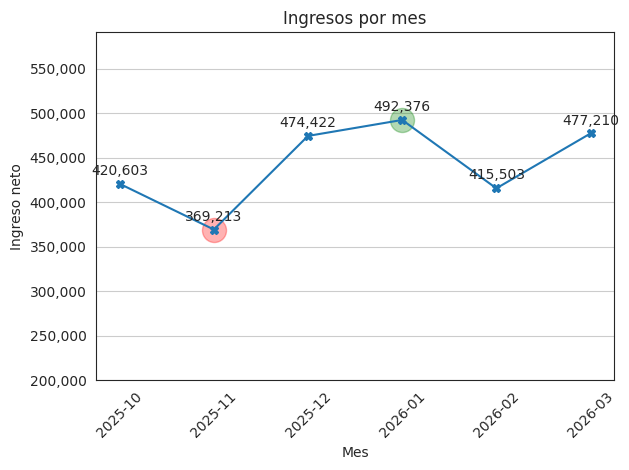

In [294]:

#preparar la grafica
plt.figure()

plt.plot(ventas_mes['mes'], ventas_mes['ingreso_neto'], marker='X')

for i, val in enumerate(ventas_mes['ingreso_neto']):
    plt.text(i, val + 10000, f"{val:,.0f}", ha='center')


# max y min
max_idx = ventas_mes['ingreso_neto'].idxmax()
min_idx = ventas_mes['ingreso_neto'].idxmin()

plt.scatter(
    ventas_mes.loc[max_idx, 'mes'],
    ventas_mes.loc[max_idx, 'ingreso_neto']
    , s=300
    , alpha=0.3
    , color='green'
)

plt.scatter(
    ventas_mes.loc[min_idx, 'mes'],
    ventas_mes.loc[min_idx, 'ingreso_neto']
    , s=300
    , alpha=0.3
    , color='red'
)

plt.title('Ingresos por mes')
plt.xlabel('Mes')
plt.ylabel('Ingreso neto')

plt.ylim(200000, ventas_mes['ingreso_neto'].max() * 1.2)

import matplotlib.ticker as mticker
plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x:,.0f}")
)


plt.xticks(rotation=45)
plt.grid(axis='y')

plt.tight_layout()
plt.show()

### Interpretación
En la tabla de ingresos se observan los ingresos mensuales y la variacion mensual, aunque en febrero 2026 el indicador de variacion es peor, a traves de la grafica podemos identifcar que el peor mes de ventas fue noviembre 2025 y el mejor enero 2026, eso explica la caida en febrero.

Importante mencionar que el analsis muestra historia de 6 meses, esto corresponde a la informacion disponble desde la implementacion del sistema; conforme los datos vayan madurando, se podrian hacer analisis de estacionalidad, tendencias y patrones.

# Productos

In [295]:
#ingresos por producto
top_productos_ingresos = (
    dataset_maestro
    .groupby('nombre_producto')['ingreso_neto']
    .sum()
    .sort_values(ascending=False) #quiero mejores ingresos
    .head(10)
    .reset_index()
)

#display(top_productos_ingresos)

#ingresos totales
total_ingresos_periodo = dataset_maestro['ingreso_neto'].sum()

print(f"Total Ingresos del Periodo (1 semestre): {total_ingresos_periodo:,.0f} \n")


#participacion por producto

top_productos_ingresos['participacion'] = (
    top_productos_ingresos['ingreso_neto'] / total_ingresos_periodo
) * 100

total_top10 = top_productos_ingresos['ingreso_neto'].sum()
participacion_top10 = (total_top10 / total_ingresos_periodo) * 100


fila_total = pd.DataFrame({
    'nombre_producto': ['Total top 10 Productos'],
    'ingreso_neto': [total_top10],
    'participacion': [participacion_top10]
})

tabla_top_productos = pd.concat(
    [top_productos_ingresos, fila_total],
    ignore_index=True
)

print('Top 10 Productos con mayorores Ingresos Netos')
tabla_display = tabla_top_productos.copy()

tabla_display['ingreso_neto'] = tabla_display['ingreso_neto'].apply(
    lambda x: f"{x:,.0f}"
)

tabla_display['participacion'] = tabla_display['participacion'].apply(
    lambda x: f"{x:.2f}%"
)

tabla_display = tabla_display.rename(columns={
    'ingreso_neto': 'Ingreso Neto (Q)'
    , 'nombre_producto': 'Producto'
    , 'participacion': '% Participacion Ingreso Neto'
})


display(tabla_display)


Total Ingresos del Periodo (1 semestre): 2,649,326 

Top 10 Productos con mayorores Ingresos Netos


,Producto,Ingreso Neto (Q),% Participacion Ingreso Neto
0,Funda Atlas,"172,358",6.51%
1,Router Apolo,"163,400",6.17%
2,Yoga Mat Oráculo,"154,181",5.82%
3,Mochila Helios,"134,288",5.07%
4,Toalla Hermes,"125,019",4.72%
5,Termo Atlas,"122,312",4.62%
6,Base Oráculo,"119,306",4.50%
7,Botella Hermes,"118,865",4.49%
8,Cable Éter,"111,913",4.22%
9,Soporte Éter,"111,790",4.22%


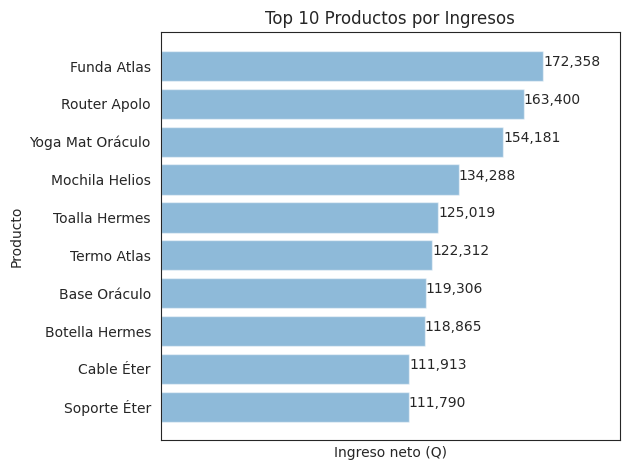

In [296]:
plt.figure()

plt.barh(
    top_productos_ingresos['nombre_producto'],
    top_productos_ingresos['ingreso_neto']
    , alpha=0.5
)

plt.gca().invert_yaxis()

plt.title('Top 10 Productos por Ingresos')
plt.xlabel('Ingreso neto (Q)')
plt.ylabel('Producto')

plt.xlim(0, top_productos_ingresos['ingreso_neto'].max() * 1.2)

#etiquetas de valores
for i, val in enumerate(top_productos_ingresos['ingreso_neto']):
    plt.text(val, i, f"{val:,.0f}")

#eliminar valores en x, para limpiar la grafica
plt.xticks([])

plt.tight_layout()
plt.show()

### Hallazgos
- El top 10 de productos, representa el 50% de los productos vendidos del total del periodo, esto indica que el balance de los productos, esta distribuida en todo el inventario.

- No se obsrva una concentracion alta en un producto en especial, por lo qu con respecto a los ingresos no se tiene dependencia en un producto een especifico.

- Se podria proponer un analisis utilizando el total de productos.

In [297]:
#ganancias por producto

top_productos_ganancia = (
    dataset_maestro
    .groupby('nombre_producto')['ganancia_neta_final']
    .sum()
    .sort_values(ascending=False) #quiero mejores ganancias
    .head(10)
    .reset_index()
)

#ganancia totales
total_ganancia_periodo = dataset_maestro['ganancia_neta_final'].sum()

print(f"Total Ganancia del Periodo (1 semestre): {total_ganancia_periodo:,.0f} \n")


#participacion por producto

top_productos_ganancia['participacion'] = (
    top_productos_ganancia['ganancia_neta_final'] / total_ganancia_periodo
) * 100

total_top10 = top_productos_ganancia['ganancia_neta_final'].sum()

participacion_top10 = (total_top10 / total_ganancia_periodo) * 100


fila_total = pd.DataFrame({
    'nombre_producto': ['Total top 10 Productos'],
    'ganancia_neta_final': [total_top10],
    'participacion': [participacion_top10]
})

tabla_top_productos_ganancia = pd.concat(
    [top_productos_ganancia, fila_total],
    ignore_index=True
)

print('Top 10 Productos con mayorores Ganancias')
tabla_display = tabla_top_productos_ganancia.copy()

tabla_display['ganancia_neta_final'] = tabla_display['ganancia_neta_final'].apply(
    lambda x: f"{x:,.0f}"
)

tabla_display['participacion'] = tabla_display['participacion'].apply(
    lambda x: f"{x:.2f}%"
)

tabla_display = tabla_display.rename(columns={
    'ganancia_neta_final': 'ganancia (Q)'
    , 'nombre_producto': 'Producto'
    , 'participacion': '% Participacion Ganancia'
})


display(tabla_display)


Total Ganancia del Periodo (1 semestre): 461,948 

Top 10 Productos con mayorores Ganancias


,Producto,ganancia (Q),% Participacion Ganancia
0,Mochila Helios,"52,784",11.43%
1,Funda Atlas,"46,580",10.08%
2,Toalla Hermes,"36,673",7.94%
3,Base Oráculo,"35,949",7.78%
4,Yoga Mat Oráculo,"30,960",6.70%
5,Botella Hermes,"28,921",6.26%
6,Archivador Hermes,"26,503",5.74%
7,Alfombra Apolo,"25,313",5.48%
8,Estante Cronos,"22,807",4.94%
9,Cámara Hermes,"20,044",4.34%


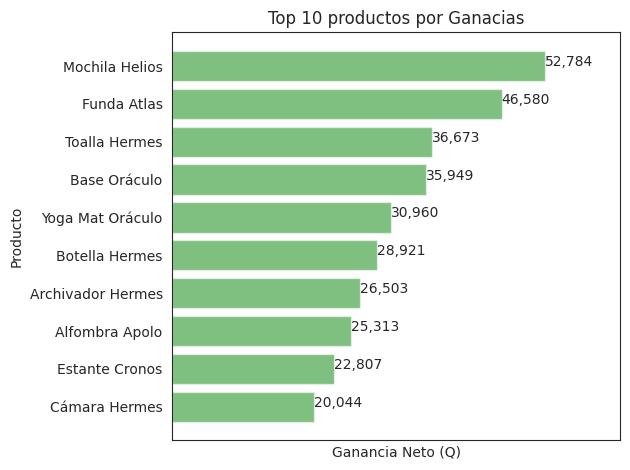

In [298]:
plt.figure()

plt.barh(
    top_productos_ganancia['nombre_producto'],
    top_productos_ganancia['ganancia_neta_final'],
    color = 'green'
    , alpha=0.5
)

plt.gca().invert_yaxis()

plt.xlim(0, top_productos_ganancia['ganancia_neta_final'].max() * 1.2)

plt.title('Top 10 productos por Ganacias')
plt.xlabel('Ganancia Neto (Q)')
plt.ylabel('Producto')

#etiquetas de valores
for i, val in enumerate(top_productos_ganancia['ganancia_neta_final']):
    plt.text(val, i, f"{val:,.0f}")

#eliminar valores en x, para limpiar la grafica
plt.xticks([])

plt.tight_layout()
plt.show()

### Hallazgos
- A diferncia del top 10 de productos por ingreso neto, el top 10 de ganancia representa el 70% de las ganancias, teniendo una concentracion del 20% en el top 2 de los productos.

- Se puede observar que existen productos de los cuales se puede obtener un mejor margen de ganancia, probablemente estrategia de precios o bien por factores estacionalidad.

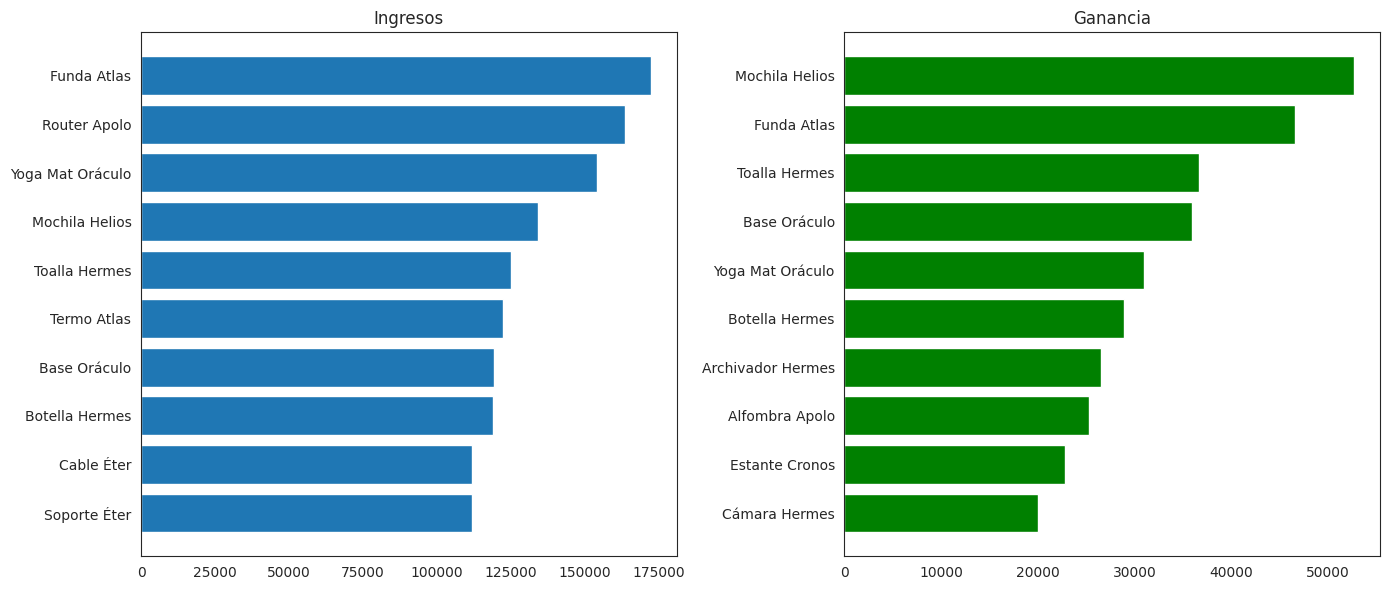

In [299]:
#ganacias vs ingresos
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

ax[0].barh(
    top_productos_ingresos['nombre_producto'],
    top_productos_ingresos['ingreso_neto']
)

ax[0].invert_yaxis()
ax[0].set_title('Ingresos')

ax[1].barh(
    top_productos_ganancia['nombre_producto'],
    top_productos_ganancia['ganancia_neta_final'],
    color='green'
)

ax[1].invert_yaxis()
ax[1].set_title('Ganancia')

plt.tight_layout()
plt.show()


### Hallazgos Ganacias vs Ingresos

- Se puede observar que el top 10 entre ganancia e ingreso difiere en productos, lo que indica que no todos los productos que generan mayores ventas son los más rentables; sin embargo la Funda Atlas sobresale en el top 3, esto sugiere un mejor desempeño ingresos - ganancias.

- Valdria la pena observar la ganancia del top de ingresos que no aparecen en la grafica de ganancia, se podria proponer una estrategia de ampliacion de ganancia, para aumentar el margen.


### Analisis top 10 Productos por Ganancas Vs Ingresos + Rentabilidad

In [300]:
comparativa_productos_g = (
    dataset_maestro
    .groupby('nombre_producto')
    .agg({
        'ingreso_neto': 'sum',
        'ganancia_neta_final': 'sum'
    })

)
# rentabilidad: ganancia (ingreso - costo) div ingreso
comparativa_productos_g['rentabilidad'] = (
    comparativa_productos_g['ganancia_neta_final'] /
    comparativa_productos_g['ingreso_neto']
) * 100

comparativa_productos_g = comparativa_productos_g.sort_values(
    by='ganancia_neta_final',
    ascending=False
)

comparativa_top_g = comparativa_productos_g.head(10).reset_index()

tabla_display = comparativa_top_g.copy()

tabla_display['ingreso_neto'] = tabla_display['ingreso_neto'].apply(
    lambda x: f"{x:,.0f}"
)

tabla_display['ganancia_neta_final'] = tabla_display['ganancia_neta_final'].apply(
    lambda x: f"{x:,.0f}"
)

#rentabilidad (%)
tabla_display['rentabilidad'] = tabla_display['rentabilidad'].apply(
    lambda x: f"{x:.2f}%"
)

tabla_display = tabla_display.rename(columns={
    'ganancia_neta_final': 'Ganancia (Q)'
    , 'ingreso_neto': 'Ingreso Neto (Q)'
    , 'nombre_producto': 'Producto'
    , 'rentabilidad': '%Rentabilidad'
})

display(tabla_display)

,Producto,Ingreso Neto (Q),Ganancia (Q),%Rentabilidad
0,Mochila Helios,"134,288","52,784",39.31%
1,Funda Atlas,"172,358","46,580",27.03%
2,Toalla Hermes,"125,019","36,673",29.33%
3,Base Oráculo,"119,306","35,949",30.13%
4,Yoga Mat Oráculo,"154,181","30,960",20.08%
5,Botella Hermes,"118,865","28,921",24.33%
6,Archivador Hermes,"104,892","26,503",25.27%
7,Alfombra Apolo,"94,379","25,313",26.82%
8,Estante Cronos,"103,519","22,807",22.03%
9,Cámara Hermes,"65,946","20,044",30.40%


In [301]:
color_continuous_scale='RdYlGn',
color_continuous_midpoint=0

fig1 = px.scatter(
    comparativa_top_g,
    x='ingreso_neto',
    y='ganancia_neta_final',
    size='rentabilidad',
    color='rentabilidad',
    color_continuous_scale='RdYlGn',
    color_continuous_midpoint=0,
    range_color=[ 10, 40],
    hover_name='nombre_producto',
    hover_data={
        'ingreso_neto': ':,.0f',
        'ganancia_neta_final': ':,.0f',
        'rentabilidad': ':.2f'
    },
    title='Ingreso, ganancia y rentabilidad por producto',
    labels={
        'ingreso_neto': 'Ingreso Neto (Q)',
        'ganancia_neta_final': 'Ganancia (Q)',
        'rentabilidad': 'Rentabilidad (%)'
    }
)

fig1.update_layout(
    xaxis_title='Ingreso Neto (Q)',
    yaxis_title='Ganancia (Q)'
)

fig1.show()

### Hallazgos
- Se observa que la rentabilidad no ordena con respecto a las ganancias para todos los productos, ya que los que muestran mayor rentabilidad, ya que le top 3 de productos con mayor rentabilidad son:
  - 1 Mochila Heelios
  - 9 Camara Hermes
  - 3 Base Oraculo

- El producto top del inventario es la Mochila Helios, con mayores ganancias y mejore rentabilidad.


### Analisis top 10 Productos por Ingresos Netos Vs Ganancias + Rentabilidad

In [302]:
comparativa_productos = (
    dataset_maestro
    .groupby('nombre_producto')
    .agg({
        'ingreso_neto': 'sum',
        'ganancia_neta_final': 'sum'
    })
)

comparativa_productos['rentabilidad'] = (
    comparativa_productos['ganancia_neta_final'] /
    comparativa_productos['ingreso_neto']
) * 100

comparativa_productos = comparativa_productos.sort_values(
    by='ingreso_neto',
    ascending=False
)

comparativa_top = comparativa_productos.head(10).reset_index()

tabla_display = comparativa_top.copy()

tabla_display['ingreso_neto'] = tabla_display['ingreso_neto'].apply(
    lambda x: f"{x:,.0f}"
)

tabla_display['ganancia_neta_final'] = tabla_display['ganancia_neta_final'].apply(
    lambda x: f"{x:,.0f}"
)

#rentabilidad (%)
tabla_display['rentabilidad'] = tabla_display['rentabilidad'].apply(
    lambda x: f"{x:.2f}%"
)


tabla_display = tabla_display.rename(columns={
    'ganancia_neta_final': 'Ganancia (Q)'
    , 'ingreso_neto': 'Ingreso Neto (Q)'
    , 'nombre_producto': 'Producto'
    , 'rentabilidad': '%Rentabilidad'
})


display(tabla_display)

,Producto,Ingreso Neto (Q),Ganancia (Q),%Rentabilidad
0,Funda Atlas,"172,358","46,580",27.03%
1,Router Apolo,"163,400","19,846",12.15%
2,Yoga Mat Oráculo,"154,181","30,960",20.08%
3,Mochila Helios,"134,288","52,784",39.31%
4,Toalla Hermes,"125,019","36,673",29.33%
5,Termo Atlas,"122,312","19,817",16.20%
6,Base Oráculo,"119,306","35,949",30.13%
7,Botella Hermes,"118,865","28,921",24.33%
8,Cable Éter,"111,913","19,480",17.41%
9,Soporte Éter,"111,790","-1,518",-1.36%


### Hallazgos
- Al igual que en las gancias se observa que el ingreso neto no ordena con respecto a la rentabilidad, esta comparacion muestra los productos con peor rentabilidad con respecto al ingreso neto, los cuals son :
  - 1 Soporte Eter
  - 9 Router Apolo
  - 3 Termo Atlas

- El peor producto del inventario es Soporte Eter, que posee una rentabilidad negativa, valdria la pena revisar al estrategia de compras y costos sobre ese producto.

### Comparativa por Productos Ganancia vs Ingreso
- El objetivo de esta grafica es clasificar a los productos a traves del %rentabilidad que es el calculo de ganancia partido el ingreos neto, esto nos permite crear un indicador de productos más valiosos y visibilizar cuales perjudican al negocio.

In [303]:


#comparativa completa por producto
comparativa_productos = (
    dataset_maestro
    .groupby('nombre_producto')
    .agg({
        'ingreso_neto': 'sum',
        'ganancia_neta_final': 'sum'
    })
    .reset_index()
)

#rentabilidad (%): porcentaje del ingreso se convierte en ganancia
comparativa_productos['rentabilidad'] = (
    comparativa_productos['ganancia_neta_final'] /
    comparativa_productos['ingreso_neto']
) * 100

#hacer 0 los negativos y calcular el tamaño de la burbuja
comparativa_productos['rentabilidad_size'] = comparativa_productos['rentabilidad'].clip(lower=0)

#promedios cuadrantes
prom_ingreso = comparativa_productos['ingreso_neto'].mean()
prom_ganancia = comparativa_productos['ganancia_neta_final'].mean()

#grafica

fig = px.scatter(
    comparativa_productos,
    x='ingreso_neto',    y='ganancia_neta_final'
    , size='rentabilidad_size'
    , color='rentabilidad'
    , color_continuous_scale='RdYlGn'
    , color_continuous_midpoint=0
    , range_color=[10, 40]
    , hover_name='nombre_producto'
    , hover_data={
        'ingreso_neto': ':,.0f',
        'ganancia_neta_final': ':,.0f',
        'rentabilidad': ':.2f',
        'rentabilidad_size': False
    },
    title='Ingreso, ganancia y rentabilidad por producto',
    labels={
        'ingreso_neto': 'Ingreso Neto (Q)',
        'ganancia_neta_final': 'Ganancia (Q)',
        'rentabilidad': 'Rentabilidad (%)'
    }
)

# Líneas de promedio para formar cuadrantes
fig.add_vline(
    x=prom_ingreso,
    line_dash='dash',
    line_color='gray'
)

fig.add_hline(
    y=prom_ganancia,
    line_dash='dash',
    line_color='gray'
)

# Etiquetas opcionales de cuadrantes
fig.add_annotation(
    x=prom_ingreso * 1.35,
    y=prom_ganancia * 1.35,
    text='Muy Rentable',
    showarrow=False
)

fig.add_annotation(
    x=prom_ingreso * 1.35,
    y=prom_ganancia * 0.60,
    text='No Rentable',
    showarrow=False
)

fig.add_annotation(
    x=prom_ingreso * 0.55,
    y=prom_ganancia * 1.35,
    text='Rentable',
    showarrow=False
)

fig.add_annotation(
    x=prom_ingreso * 0.55,
    y=prom_ganancia * 0.60,
    text='En Riesgo',
    showarrow=False
)

fig.update_layout(
    xaxis_title='Ingreso Neto (Q)',
    yaxis_title='Ganancia (Q)'
)

fig.show()

Como se observa en la grafica, el tamaño y color de la burbuja muestran el % de la rentabilidad en donde el cuadrante superior derecho es el mejor y el inferior dereche es el peor.

La clasificación propuesta es la siguiente (de mejor a peor):
- Muy rentable
- Rentable
- En Riesgo
- No Rentable

### Ventas por Canal

,Canal de Venta,Ingreso Neto (Q),%Participacion
0,online,"1,213,699",45.81%
1,tienda,"916,837",34.61%
2,app,"518,790",19.58%
3,Total,"2,649,326",100.00%


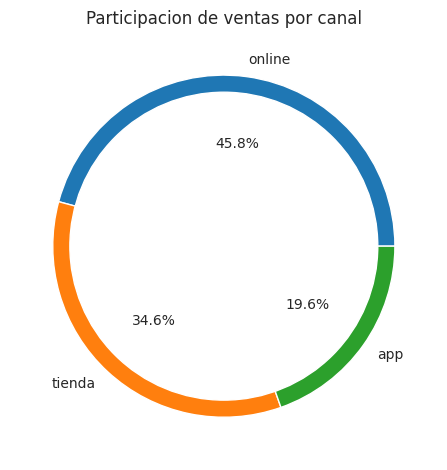

In [304]:
ventas_canal = (
    dataset_maestro
    .groupby('canal')['ingreso_neto']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

total_ingresos = ventas_canal['ingreso_neto'].sum()

ventas_canal['participacion'] = (
    ventas_canal['ingreso_neto'] / total_ingresos
) * 100


plt.figure()

plt.pie(
    ventas_canal['ingreso_neto'],
    labels=ventas_canal['canal'],
    autopct='%1.1f%%'

)

# agregar el total
gran_total = pd.DataFrame({
    'canal': ['Total'],
    'ingreso_neto': [total_ingresos],
    'participacion': [100]
})

ventas_canal = pd.concat(
    [ventas_canal, gran_total],
    ignore_index=True
)


# display
tabla_display = ventas_canal.copy()

tabla_display['ingreso_neto'] = tabla_display['ingreso_neto'].apply(
    lambda x: f"{x:,.0f}"
)

tabla_display['participacion'] = tabla_display['participacion'].apply(
    lambda x: f"{x:.2f}%"
)

tabla_display = tabla_display.rename(columns={
    'canal': 'Canal de Venta',
    'ingreso_neto': 'Ingreso Neto (Q)',
    'participacion': '%Participacion'
})


display(tabla_display)



# agujero tipo donut
centre_circle = plt.Circle((0, 0), 0.90, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Participacion de ventas por canal')

plt.tight_layout()
plt.show()


In [305]:
estados_entrega = (
    dataset_maestro
    .groupby('estado_entrega')
    .size()
    .reset_index(name='cantidad')
    .sort_values(by='cantidad', ascending=False)
)

total = estados_entrega['cantidad'].sum()

estados_entrega['participacion'] = (
    estados_entrega['cantidad'] / total
) * 100

tabla_display = estados_entrega.copy()

tabla_display['participacion'] = tabla_display['participacion'].apply(
    lambda x: f"{x:.2f}%"
)

display(tabla_display)


,estado_entrega,cantidad,participacion
1,entregado,1238,74.35%
2,tardío,365,21.92%
0,cancelado,62,3.72%


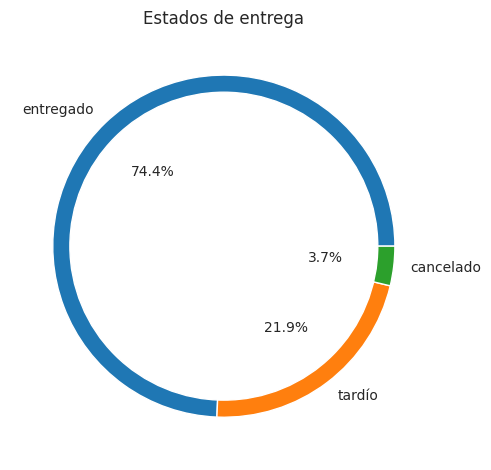

In [306]:

# estilo seaborn
sns.set_style("white")

plt.figure()

plt.pie(
    estados_entrega['cantidad'],
    labels=estados_entrega['estado_entrega'],
    autopct='%1.1f%%'
)

centre_circle = plt.Circle((0, 0), 0.90, fc='white')
plt.gca().add_artist(centre_circle)

plt.title('Estados de entrega')

plt.tight_layout()
plt.show()

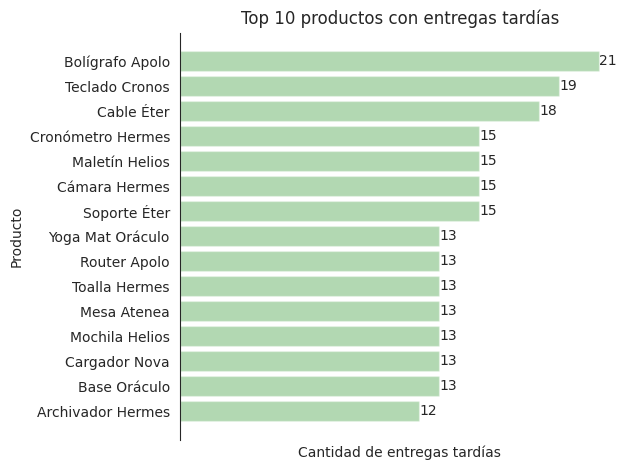

In [307]:
tardios = dataset_maestro[
    dataset_maestro['estado_entrega'] == 'tardío'
]

top_productos_tardios = (
    tardios
    .groupby('nombre_producto')
    .size()
    .reset_index(name='cantidad_tardios')
    .sort_values(by='cantidad_tardios', ascending=False)
    .head(15)
)


plt.figure()

plt.barh(
    top_productos_tardios['nombre_producto'],
    top_productos_tardios['cantidad_tardios'],
    alpha=0.3,
    color = "green"
)

plt.gca().invert_yaxis()

plt.title('Top 10 productos con entregas tardías')
plt.xlabel('Cantidad de entregas tardías')
plt.ylabel('Producto')

for i, val in enumerate(top_productos_tardios['cantidad_tardios']):
    plt.text(val, i, f"{val}", va='center')

for spine in ['top', 'right', 'bottom']:
    plt.gca().spines[spine].set_visible(False)

plt.xticks([])
plt.tight_layout()
plt.show()



,motivo_devolucion,cantidad,participacion
0,defectuoso,68,34.34%
1,entrega tardia,48,24.24%
2,no le gusto,48,24.24%
3,producto incorrecto,34,17.17%


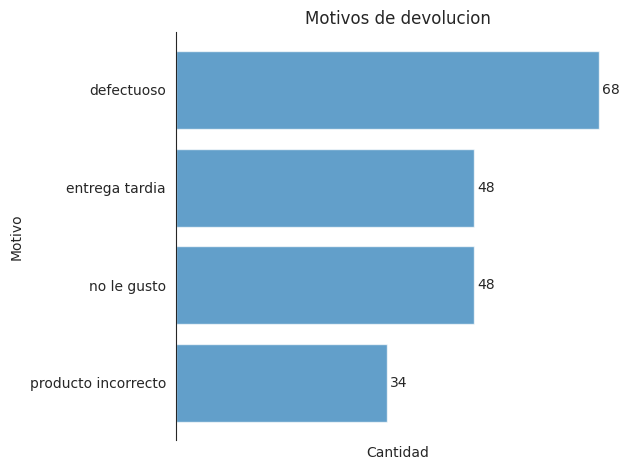

In [308]:
motivos = dataset_maestro[
    dataset_maestro['motivo_devolucion'] != 'No aplica'
]

motivos = (
    motivos
    .groupby('motivo_devolucion')
    .size()
    .reset_index(name='cantidad')
    .sort_values(by='cantidad', ascending=False)
)

total = motivos['cantidad'].sum()

motivos['participacion'] = (
    motivos['cantidad'] / total
) * 100

tabla_display = motivos.copy()

tabla_display['participacion'] = tabla_display['participacion'].apply(
    lambda x: f"{x:.2f}%"
)

display(tabla_display)

plt.figure()

plt.barh(
    motivos['motivo_devolucion'],
    motivos['cantidad'],
    alpha=0.7
)

plt.gca().invert_yaxis()

plt.title('Motivos de devolucion')
plt.xlabel('Cantidad')
plt.ylabel('Motivo')

# etiquetas
for i, val in enumerate(motivos['cantidad']):
    plt.text(val + 0.5, i, f"{val}", va='center')

plt.xticks([])
for spine in ['top', 'right', 'bottom']:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

In [309]:
defectuosos = dataset_maestro[
    dataset_maestro['motivo_devolucion'] == 'defectuoso'
]

top_defectuosos = (
    defectuosos
    .groupby('nombre_producto')
    .size()
    .reset_index(name='cantidad_defectuosos')
    .sort_values(by='cantidad_defectuosos', ascending=False)
)

metricas_producto = (
    dataset_maestro
    .groupby('nombre_producto')
    .agg({
        'ingreso_neto': 'sum',
        'ganancia_neta_final': 'sum'
    })
    .reset_index()
)

metricas_producto['rentabilidad'] = (
    metricas_producto['ganancia_neta_final'] /
    metricas_producto['ingreso_neto']
) * 100

metricas_producto = (
    dataset_maestro
    .groupby('nombre_producto')
    .agg({
        'ingreso_neto': 'sum',
        'ganancia_neta_final': 'sum'
    })
    .reset_index()
)

metricas_producto['rentabilidad'] = (
    metricas_producto['ganancia_neta_final'] /
    metricas_producto['ingreso_neto']
) * 100

comparativa_defectuosos = top_defectuosos.merge(
    metricas_producto,
    on='nombre_producto',
    how='left'
)

comparativa_defectuosos = comparativa_defectuosos.head(15)

tabla_display = comparativa_defectuosos.copy()

tabla_display['ingreso_neto'] = tabla_display['ingreso_neto'].apply(
    lambda x: f"{x:,.0f}"
)

tabla_display['ganancia_neta_final'] = tabla_display['ganancia_neta_final'].apply(
    lambda x: f"{x:,.0f}"
)

tabla_display['rentabilidad'] = tabla_display['rentabilidad'].apply(
    lambda x: f"{x:.2f}%"
)

tabla_display = tabla_display.rename(columns={
    'nombre_producto': 'Producto',
    'cantidad_defectuosos': 'Devoluciones defectuosas',
    'ingreso_neto': 'Ingreso (Q)',
    'ganancia_neta_final': 'Ganancia (Q)',
    'rentabilidad': 'Rentabilidad (%)'
})

display(tabla_display)



,Producto,Devoluciones defectuosas,Ingreso (Q),Ganancia (Q),Rentabilidad (%)
0,Maletín Helios,5,"85,862",-350,-0.41%
1,Toalla Hermes,5,"125,019","36,673",29.33%
2,Teclado Cronos,4,"11,083","-2,482",-22.40%
3,Lámpara Éter,4,"61,540","2,980",4.84%
4,Archivador Hermes,4,"104,892","26,503",25.27%
5,Yoga Mat Oráculo,4,"154,181","30,960",20.08%
6,Mesa Atenea,3,"81,105","9,071",11.18%
7,Router Apolo,3,"163,400","19,846",12.15%
8,Funda Atlas,3,"172,358","46,580",27.03%
9,Cable Éter,3,"111,913","19,480",17.41%


In [310]:
comparativa_defectuosos['size'] = comparativa_defectuosos['cantidad_defectuosos']

fig = px.scatter(
    comparativa_defectuosos,
    x='ingreso_neto',
    y='cantidad_defectuosos',
    size='size',
    color='rentabilidad',
    color_continuous_scale='RdYlGn',
    color_continuous_midpoint=0,
    range_color=[-5, 25],
    hover_name='nombre_producto',
    hover_data={
        'ingreso_neto': ':,.0f',
        'cantidad_defectuosos': True,
        'rentabilidad': ':.2f'
    },
    title='Devoluciones defectuosas vs ingreso por producto',
    labels={
        'ingreso_neto': 'Ingreso (Q)',
        'cantidad_defectuosos': 'Devoluciones defectuosas',
        'rentabilidad': 'Rentabilidad (%)'
    }
)

fig.show()

Se identifican productos con incidencias de devoluciones por defectos que, además, presentan niveles bajos o negativos de rentabilidad, lo que sugiere un impacto directo en la eficiencia del negocio

,cliente_id,cantidad_devoluciones
136,245,4
5,8,3
42,88,3
117,212,3
132,238,3
101,188,3
76,149,3
84,161,3
112,205,3
121,216,3


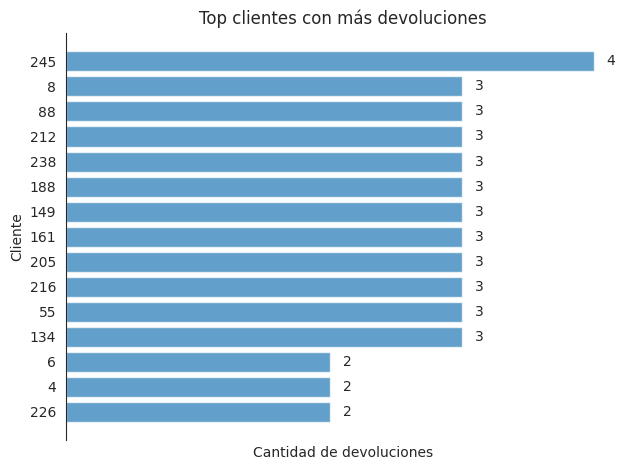

In [311]:
devoluciones_reales = dataset_maestro[
    dataset_maestro['motivo_devolucion'] != 'No aplica'
]

clientes_devoluciones = (
    devoluciones_reales
    .groupby('cliente_id')
    .size()
    .reset_index(name='cantidad_devoluciones')
    .sort_values(by='cantidad_devoluciones', ascending=False)
)

top_clientes_devoluciones = clientes_devoluciones.head(15)
display(top_clientes_devoluciones)

plt.figure()

plt.barh(
    top_clientes_devoluciones['cliente_id'].astype(str),
    top_clientes_devoluciones['cantidad_devoluciones'],
    alpha=0.7
)

plt.gca().invert_yaxis()

plt.title('Top clientes con más devoluciones')
plt.xlabel('Cantidad de devoluciones')
plt.ylabel('Cliente')

for i, val in enumerate(top_clientes_devoluciones['cantidad_devoluciones']):
    plt.text(val + 0.1, i, f"{val}", va='center')

plt.xticks([])
for spine in ['top', 'right', 'bottom']:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.show()


## **Clientes**

###**Por Ingresos**

In [312]:
top_clientes_ingreso = (
    dataset_maestro
    .groupby(['cliente_id'])['ingreso_neto']
    .sum()
    .sort_values(ascending=False)
    .head(25)
    .reset_index()
)

total_ingresos = dataset_maestro['ingreso_neto'].sum()

top_clientes_ingreso['participacion'] = (
    top_clientes_ingreso['ingreso_neto'] / total_ingresos
) * 100


otros_ingresos = total_ingresos - total_top10
participacion_otros = (otros_ingresos / total_ingresos) * 100

fila_otros = pd.DataFrame({
    'cliente_id': ['Otros'],
    'ingreso_neto': [otros_ingresos],
    'participacion': [participacion_otros]
})

top_clientes_ingreso = pd.concat(
    [top_clientes_ingreso, fila_otros],
    ignore_index=True
)

tabla_display = top_clientes_ingreso.copy()

tabla_display['ingreso_neto'] = tabla_display['ingreso_neto'].apply(
    lambda x: f"{x:,.0f}"
)

tabla_display['participacion'] = tabla_display['participacion'].apply(
    lambda x: f"{x:.2f}%"
)


tabla_display = tabla_display.rename(columns={
    'cliente_id': 'Codigo de Cliente'
    , 'ingreso_neto': 'Ingreso Neto (Q)'
    , 'participacion': '%Participacion'
})


display(tabla_display)

total_top10 = top_clientes_ingreso['ingreso_neto'].sum()
participacion_top10 = (total_top10 / total_ingresos) * 100

total_clientes = dataset_maestro['cliente_id'].nunique()
print(f"Total de clientes: {total_clientes}")

porcentaje_top10_clientes = (25 / total_clientes) * 100
print(f"Top 25 representa el {porcentaje_top10_clientes:.2f}% de los clientes")


,Codigo de Cliente,Ingreso Neto (Q),%Participacion
0,149,"30,580",1.15%
1,86,"26,926",1.02%
2,161,"24,503",0.92%
3,141,"23,275",0.88%
4,144,"21,673",0.82%
5,125,"21,415",0.81%
6,227,"21,357",0.81%
7,183,"20,979",0.79%
8,20,"20,596",0.78%
9,220,"20,572",0.78%


Total de clientes: 250
Top 25 representa el 10.00% de los clientes


**Por Ganancias**

In [313]:
top_clientes_ganancia = (
    dataset_maestro
    .groupby(['cliente_id'])['ganancia_neta_final']
    .sum()
    .sort_values(ascending=False)
    .head(25)
    .reset_index()
)

# total ganancia del periodo
total_ganancia = dataset_maestro['ganancia_neta_final'].sum()

# participacion
top_clientes_ganancia['participacion'] = (
    top_clientes_ganancia['ganancia_neta_final'] / total_ganancia
) * 100

# total del top 25
total_top25 = top_clientes_ganancia['ganancia_neta_final'].sum()

# otros
otros_ganancia = total_ganancia - total_top25
participacion_otros = (otros_ganancia / total_ganancia) * 100

# fila otros
fila_otros = pd.DataFrame({
    'cliente_id': ['Otros'],
    'ganancia_neta_final': [otros_ganancia],
    'participacion': [participacion_otros]
})

# unir
top_clientes_ganancia = pd.concat(
    [top_clientes_ganancia, fila_otros],
    ignore_index=True
)

# display
tabla_display = top_clientes_ganancia.copy()

tabla_display['ganancia_neta_final'] = tabla_display['ganancia_neta_final'].apply(
    lambda x: f"{x:,.0f}"
)

tabla_display['participacion'] = tabla_display['participacion'].apply(
    lambda x: f"{x:.2f}%"
)

tabla_display = tabla_display.rename(columns={
    'cliente_id': 'Codigo de Cliente',
    'ganancia_neta_final': 'Ganancia (Q)',
    'participacion': '%Participacion'
})

display(tabla_display)

# info adicional
total_clientes = dataset_maestro['cliente_id'].nunique()
print(f"Total de clientes: {total_clientes}")

porcentaje_top25_clientes = (25 / total_clientes) * 100
print(f"Top 25 representa el {porcentaje_top25_clientes:.2f}% de los clientes")

,Codigo de Cliente,Ganancia (Q),%Participacion
0,72,"7,389",1.60%
1,149,"7,323",1.59%
2,86,"7,256",1.57%
3,220,"6,874",1.49%
4,69,"6,584",1.43%
5,128,"6,274",1.36%
6,119,"6,224",1.35%
7,110,"5,842",1.26%
8,227,"5,831",1.26%
9,175,"5,635",1.22%


Total de clientes: 250
Top 25 representa el 10.00% de los clientes


### Hallazgos:
 - Se observa en la tabla que el ingreso neto esta distribuido por toda la cartera de clientes, siendo el total de 250 clintes.

- El cliente con mayor participación representa aproximadamente el 1.15% del ingreso total.

- Por lo anterior el indicador muestra que existe baja dependencia de clientes individuales.


### Top 15 Clientes
  - Devoluciones
  - Ingreso Neto (Q)
  - Ganancia (Q)
  - Rentabilidad (%)

In [314]:
metricas_cliente = (
    dataset_maestro
    .groupby('cliente_id')
    .agg({
        'ingreso_neto': 'sum',
        'ganancia_neta_final': 'sum'
    })
    .reset_index()
)

metricas_cliente['rentabilidad'] = (
    metricas_cliente['ganancia_neta_final'] /
    metricas_cliente['ingreso_neto']
) * 100

comparativa_clientes_devoluciones = top_clientes_devoluciones.merge(
    metricas_cliente,
    on='cliente_id',
    how='left'
)

tabla_display = comparativa_clientes_devoluciones.copy()

tabla_display['ingreso_neto'] = tabla_display['ingreso_neto'].apply(
    lambda x: f"{x:,.0f}"
)

tabla_display['ganancia_neta_final'] = tabla_display['ganancia_neta_final'].apply(
    lambda x: f"{x:,.0f}"
)

tabla_display['rentabilidad'] = tabla_display['rentabilidad'].apply(
    lambda x: f"{x:.2f}%"
)

tabla_display = tabla_display.rename(columns={
    'cliente_id': 'Codigo de Cliente',
    'cantidad_devoluciones': 'Devoluciones',
    'ingreso_neto': 'Ingreso Neto (Q)',
    'ganancia_neta_final': 'Ganancia (Q)',
    'rentabilidad': 'Rentabilidad (%)'
})

display(tabla_display)


,Codigo de Cliente,Devoluciones,Ingreso Neto (Q),Ganancia (Q),Rentabilidad (%)
0,245,4,"15,135","-6,275",-41.46%
1,8,3,"16,506","2,831",17.15%
2,88,3,"7,808",-631,-8.08%
3,212,3,"9,531",-14,-0.15%
4,238,3,"14,637","-3,861",-26.38%
5,188,3,"15,894",-499,-3.14%
6,149,3,"30,580","7,323",23.95%
7,161,3,"24,503","5,063",20.66%
8,205,3,"4,731","-2,704",-57.16%
9,216,3,"13,874","3,061",22.07%


### Hallazgos

- Existen clientes con alta incidencia de devoluciones que tambien tienen niveles negativos de rentabilidad.

-Esto representa una perdida para el negocio clientes con devoluciones + productos con baja rentabilidad

### Clasificacion de Clientes

Debido a la distribucion y los datos de los clientes se propone hacer una clasificacion de clientes, de acuerdo a cuantas veces compra el cliente y la ultima vez que compro.

Esto observando los 6 meses que se tienen disponibles de compras de clientes.

### Frecuencia de Cientes

Cuantas veces compro el cliente durante el periodo de tiempo evaluado

In [315]:
frecuencia_clientes = (
    dataset_maestro
    .groupby('cliente_id')
    .size()
    .reset_index(name='frecuencia_compra')
    .sort_values(by='frecuencia_compra', ascending=False)
)

frecuencia_clientes['frecuencia_compra'].describe()


,frecuencia_compra
count,250.000000
mean,6.708000
std,2.575513
min,1.000000
25%,5.000000
50%,7.000000
75%,8.000000
max,18.000000


Con el describe podemos observar la distrubicion de la frecuencia, con base a esto se procedera a marcar a los clientes de mejor a peor frecuencia.

In [316]:
frecuencia_clientes['segmento_frecuencia'] = pd.cut(
    frecuencia_clientes['frecuencia_compra'],
    bins=[0, 5, 7, 100],
    labels=['bajo', 'medio', 'alto']
)
dist = frecuencia_clientes['segmento_frecuencia'].value_counts(normalize=True) * 100
print(dist)

segmento_frecuencia
alto     36.8
bajo     34.0
medio    29.2
Name: proportion, dtype: float64


### Ultima compra del Cliente

Ah esta variable le llamaremos recencia, y se aplicara una resta partiendo desde hoy hasta la ultima fecha que compro.

In [317]:
recencia_clientes = (
    dataset_maestro
    .groupby('cliente_id')['fecha']
    .max()
    .reset_index()
)

hoy = dataset_maestro['fecha'].max()

recencia_clientes['recencia'] = (
    hoy - recencia_clientes['fecha']
).dt.days

recencia_clientes['recencia'].describe()

,recencia
count,250.00000
mean,25.74400
std,25.43277
min,0.00000
25%,8.00000
50%,17.50000
75%,37.75000
max,135.00000


Con el describe podemos observar la distrubicion de la recencia, con base a esto se procedera a marcar a los clientes de mejor a peor recencia.

In [318]:
recencia_clientes['segmento_recencia'] = pd.cut(
    recencia_clientes['recencia'],
    bins=[-1, 8, 18, 9999],
    labels=['reciente', 'intermedio', 'inactivo']
)
recencia_clientes['segmento_recencia'].value_counts()

,count
segmento_recencia,
inactivo,119
reciente,72
intermedio,59


### Monto Clientes
El monto clientes representa el valor de los clientes, se procedera a sumar todas las compras del periodo.

In [319]:
monto_clientes = (
    dataset_maestro
    .groupby('cliente_id')['ingreso_neto']
    .sum()
    .reset_index(name='monto_total')
    .sort_values(by='monto_total', ascending=False)
)

monto_clientes['monto_total'].describe()


,monto_total
count,250.000000
mean,10597.305206
std,5138.340429
min,163.026000
25%,6794.817000
50%,9912.490500
75%,13765.777875
max,30579.503500


Al igual que en las anteriores variables, se procede a marcar los clientes de mejor a peor de acuerdo a los rangos de montos dentro del periodo evaluado.

In [320]:
monto_clientes['segmento_monto'] = pd.cut(
    monto_clientes['monto_total'],
    bins=[-1, 8000, 15000, 999999999],
    labels=['bajo valor', 'medio valor', 'alto valor']
)
monto_clientes['segmento_monto'].value_counts()

,count
segmento_monto,
medio valor,120
bajo valor,83
alto valor,47


### Analisis RFM

A partir de las segmentaciones de frecuencia, recencia y monto, se realiza un merge de las tres clasificaciones para obtener una final de clientes.

A diferencia del modelo RFM clasico basado en scores, esta segmentación se construira combinando directamente las categorías de cada variable que se realizaron anteriormente.

El segmento final del cliente sera el siguiente:

- Premium clientes con alta frecuencia, compra reciente y valor monetario no bajo

- Preferencial clientes con señales relevantes de valor o actividad

- El resto de clientes se clasifica como estandar

In [321]:
#merge
rf = frecuencia_clientes[['cliente_id', 'segmento_frecuencia']].merge(
    recencia_clientes[['cliente_id', 'segmento_recencia']],
    on='cliente_id',
    how='left'
)

rfm = rf.merge(
    monto_clientes[['cliente_id', 'segmento_monto']],
    on='cliente_id',
    how='left'
)

In [322]:
display(rfm.head())

,cliente_id,segmento_frecuencia,segmento_recencia,segmento_monto
0,149,alto,intermedio,alto valor
1,227,alto,reciente,alto valor
2,161,alto,reciente,alto valor
3,108,alto,intermedio,alto valor
4,120,alto,intermedio,alto valor


In [323]:
# inicializacion de clientes, por defecto estandar (else)
rfm['segmento_final'] = 'cliente estandar'


# preferencial
# montos altos, frecuencia media, reciente o alta
rfm.loc[
    (
        (rfm['segmento_monto'] == 'alto valor') |
        (rfm['segmento_frecuencia'] == 'alto') |
        (
            (rfm['segmento_frecuencia'] == 'medio') &
            (rfm['segmento_recencia'] == 'reciente')
        )
    ),
    'segmento_final'
] = 'cliente preferencial'


# premium
# alta frecuencia, compras reciente y montos que no sea bajo.

rfm.loc[
    (
        (rfm['segmento_frecuencia'] == 'alto') &
        (rfm['segmento_recencia'] == 'reciente') &
        (rfm['segmento_monto'].isin(['medio valor', 'alto valor']))
    ),
    'segmento_final'
] = 'cliente premium'

# distribucion final
distribucion_segmentos = rfm['segmento_final'].value_counts().reset_index()
distribucion_segmentos.columns = ['segmento', 'cantidad']
distribucion_segmentos['porcentaje'] = (
    distribucion_segmentos['cantidad'] / distribucion_segmentos['cantidad'].sum() * 100
).round(2)

display(distribucion_segmentos)


,segmento,cantidad,porcentaje
0,cliente estandar,132,52.8
1,cliente preferencial,84,33.6
2,cliente premium,34,13.6


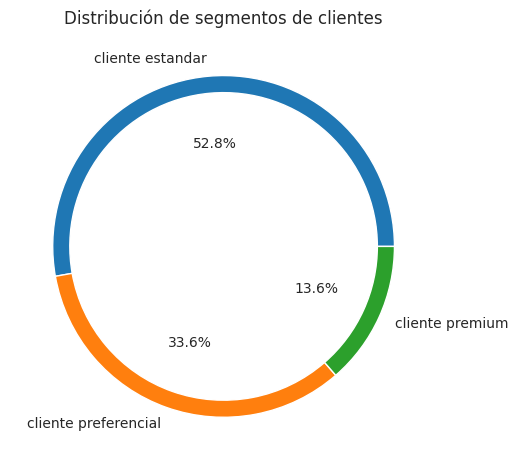

In [324]:
#grafica de distribucion

plt.figure()

plt.pie(
    distribucion_segmentos['cantidad'],
    labels=distribucion_segmentos['segmento'],
    autopct='%1.1f%%',
    wedgeprops={'width': 0.1}
)

plt.title('Distribución de segmentos de clientes')

plt.tight_layout()
plt.show()

###Conclusiones

- La concentracion se encuentra en clientes estandar, mientras que la menor se encuentra en premium.

- Esto indica que la distrubicion siendo los mejores menos y los peores mas.

- Con esta distribucion final se peuden plantear estrategias de crecimiento y fidelidad del cliente.